# Economics 5040: Dynamic Stochastic Modeling
## Problem Set 1 — **Solutions**
### Intertemporal Choice, Production, and Equilibrium

This notebook contains complete derivations, code, figures, numerical answers, and economic
explanations for every part of Problem Set 1.

**Roadmap.**

| Problem | Topic | Key result |
|---|---|---|
| 1 | Utility and ordinal rankings | Monotone transformations preserve orderings; $MRS_{1,2}=\beta c_1/c_2$ |
| 2 | Two-period exchange economy | $c_0^*=W/(1+\beta)$, $c_1^*=\beta R c_0^*$, $MRS=R$ |
| 3 | Intertemporal production / planner | $k_0^*=\dfrac{\alpha\beta y_0}{1+\alpha\beta}$, $MRS=MRT$ |
| 4 | Decentralization | $R^*=f'(k_0^*)$ supports the planner allocation |
| 5 | Disequilibrium and market clearing | $Z(R)=k^d(R)-s(R)=0$ at $R=R^*$ |
| 6 | First Welfare Theorem | Computation illustrates, it does not prove |
| 7 | Synthesis | $MRS=R=MRT$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar, brentq

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

---
# Problem 1. Utility, Rankings, and Intertemporal Preferences

Consider
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$

### (a)
Define the utility function, evaluate plans A, B, and C, and rank them.

In [2]:
beta = 0.95


def U(c0, c1, beta=beta):
    """Time-separable log utility over a two-period consumption plan."""
    return np.log(c0) + beta * np.log(c1)


A = (4.0, 4.0)
B = (3.0, 6.0)
C = (5.0, 3.0)

plans = {"A": A, "B": B, "C": C}
vals = {name: U(*bundle) for name, bundle in plans.items()}

for name, bundle in plans.items():
    print(f"Plan {name} = (c0, c1) = {bundle}:   U = {vals[name]: .6f}")

order = sorted(vals, key=vals.get, reverse=True)
print("\nRanking (best to worst):", "  >  ".join(order))

Plan A = (c0, c1) = (4.0, 4.0):   U =  2.703274
Plan B = (c0, c1) = (3.0, 6.0):   U =  2.800784
Plan C = (c0, c1) = (5.0, 3.0):   U =  2.653120

Ranking (best to worst): B  >  A  >  C


**Answer (a).**

$$
U(A)=\log 4+0.95\log 4 = 2.703274,\qquad
U(B)=\log 3+0.95\log 6 = 2.800784,\qquad
U(C)=\log 5+0.95\log 3 = 2.653120 .
$$

Therefore

$$
\boxed{B \succ A \succ C.}
$$

*Economics.* Plan $B$ front-loads less consumption ($c_0=3$) but delivers a much larger $c_1=6$.
Because $\beta=0.95$ is close to $1$, the agent is patient and the concavity of $\log$ makes the
smoother-in-marginal-utility, future-heavy plan attractive. Plan $C$ is the most front-loaded and
ranks last: the marginal utility gain from the fifth unit of $c_0$ is small relative to the loss from
cutting $c_1$ from $4$ to $3$.

### (b)
Define the monotone transformation $V(c_0,c_1)=\exp(U(c_0,c_1))$. Verify that the ranking is unchanged and explain why.

In [3]:
def V(c0, c1, beta=beta):
    """Strictly increasing transformation of U:  V = exp(U) = c0 * c1**beta."""
    return np.exp(U(c0, c1, beta))


vals_V = {name: V(*bundle) for name, bundle in plans.items()}

print(f"{'plan':<6}{'U':>14}{'V = exp(U)':>16}{'c0 * c1**beta':>18}")
for name, bundle in plans.items():
    closed_form = bundle[0] * bundle[1] ** beta
    print(f"{name:<6}{vals[name]:>14.6f}{vals_V[name]:>16.6f}{closed_form:>18.6f}")

order_V = sorted(vals_V, key=vals_V.get, reverse=True)
print("\nRanking under U:", "  >  ".join(order))
print("Ranking under V:", "  >  ".join(order_V))
print("Rankings identical:", order == order_V)

plan               U      V = exp(U)     c0 * c1**beta
A           2.703274       14.928528         14.928528
B           2.800784       16.457541         16.457541
C           2.653120       14.198262         14.198262

Ranking under U: B  >  A  >  C
Ranking under V: B  >  A  >  C
Rankings identical: True


**Answer (b).** The ranking is again $B \succ A \succ C$.

*Why.* $V=\varphi(U)$ with $\varphi(x)=e^{x}$, and $\varphi'(x)=e^{x}>0$, so $\varphi$ is a **strictly
increasing** function on $\mathbb{R}$. Hence for any two bundles $x,y$,

$$
U(x) > U(y) \iff e^{U(x)} > e^{U(y)} \iff V(x) > V(y),
$$

so $U$ and $V$ represent the *same* preference relation $\succeq$. Utility is an **ordinal** object:
only the ordering of the numbers matters, not the numbers themselves. Note also that
$V(c_0,c_1)=c_0 c_1^{\beta}$, i.e. exponentiating the log-utility recovers a Cobb–Douglas
representation — the same preferences written differently.

Two caveats worth stating: (i) the *cardinal* magnitudes change (differences and ratios of utility are
not preserved), and (ii) any object defined purely by the ordering is invariant. In particular the MRS
is invariant, since
$$
MRS^V_{0,1}=\frac{V_1}{V_2}\Big|_{\varphi'\ \text{cancels}}
=\frac{\varphi'(U)U_{c_0}}{\varphi'(U)U_{c_1}}=\frac{U_{c_0}}{U_{c_1}}=MRS^U_{0,1}.
$$

### (c)
Create a grid of at least 10,000 positive bundles. Verify numerically that $U$ and $V$ induce the same ranking.

In [4]:
grid = np.linspace(0.25, 10.0, 100)          # 100 x 100 = 10,000 strictly positive bundles
C0, C1 = np.meshgrid(grid, grid, indexing="ij")

U_vals = U(C0, C1)
V_vals = V(C0, C1)
print("number of bundles evaluated:", U_vals.size)

# --- Test 1: the induced orderings (permutations of the bundles) coincide -----------
rank_U = np.argsort(U_vals, axis=None, kind="stable")
rank_V = np.argsort(V_vals, axis=None, kind="stable")
print("identical sort order:", np.array_equal(rank_U, rank_V))

# --- Test 2: exhaustive-in-spirit pairwise sign test on 2,000,000 random pairs ------
rng = np.random.default_rng(0)
u_flat, v_flat = U_vals.ravel(), V_vals.ravel()
i = rng.integers(0, u_flat.size, 2_000_000)
j = rng.integers(0, u_flat.size, 2_000_000)

dU = u_flat[i] - u_flat[j]
dV = v_flat[i] - v_flat[j]
disagree = np.sign(dU) != np.sign(dV)
print("pairwise comparisons tested :", dU.size)
print("sign disagreements          :", int(disagree.sum()))
print("max |dU| among disagreements:", float(np.abs(dU[disagree]).max()) if disagree.any() else 0.0)

# --- Test 3: V is a strictly increasing function of U -------------------------------
s = np.argsort(u_flat, kind="stable")
print("V is nondecreasing along the U-ordering:", bool(np.all(np.diff(v_flat[s]) >= 0)))

number of bundles evaluated: 10000
identical sort order: True
pairwise comparisons tested : 2000000
sign disagreements          : 0
max |dU| among disagreements: 0.0
V is nondecreasing along the U-ordering: True


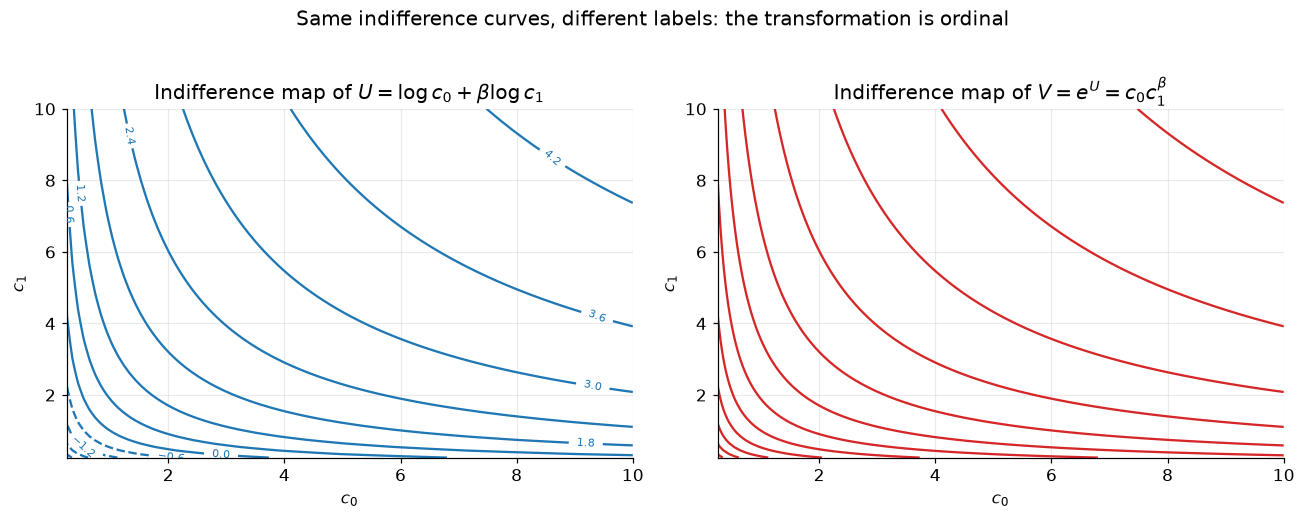

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.6))

lv = ax[0].contour(C0, C1, U_vals, levels=12, colors="tab:blue")
ax[0].clabel(lv, inline=True, fontsize=7)
ax[0].set_title(r"Indifference map of $U=\log c_0+\beta\log c_1$")

lv = ax[1].contour(C0, C1, V_vals, levels=np.exp(lv.levels), colors="tab:red")
ax[1].set_title(r"Indifference map of $V=e^{U}=c_0c_1^{\beta}$")

for a in ax:
    a.set_xlabel(r"$c_0$")
    a.set_ylabel(r"$c_1$")

fig.suptitle("Same indifference curves, different labels: the transformation is ordinal", y=1.02)
fig.tight_layout()
plt.show()

**Answer (c).** Over all $10{,}000$ grid bundles the two functions produce the *identical* sort
permutation, and among $2{,}000{,}000$ randomly drawn pairs there is not a single reversal of the sign
of the comparison. The contour plots make the point geometrically: the indifference *curves* are the
same set of curves in $(c_0,c_1)$ space; only the numbers attached to them differ (level $u$ becomes
level $e^{u}$). Since the level sets and their ordering are unchanged, the preference relation is
unchanged.

### (d)

For
$$
U(c_0,c_1,c_2)=\log c_0+\beta\log c_1+\beta^2\log c_2,
$$
derive the MRS between $c_1$ and $c_2$. Explain why $c_0$ does not appear and what this says about time-separable preferences.

**Answer (d).**

Marginal utilities:
$$
\frac{\partial U}{\partial c_0}=\frac{1}{c_0},\qquad
\frac{\partial U}{\partial c_1}=\frac{\beta}{c_1},\qquad
\frac{\partial U}{\partial c_2}=\frac{\beta^{2}}{c_2}.
$$

The marginal rate of substitution of $c_2$ for $c_1$ — how many units of $c_2$ compensate the loss of
one unit of $c_1$ along an indifference surface — is
$$
MRS_{1,2}\;=\;-\frac{dc_2}{dc_1}\bigg|_{dU=0}
\;=\;\frac{\partial U/\partial c_1}{\partial U/\partial c_2}
\;=\;\frac{\beta/c_1}{\beta^{2}/c_2}
\;=\;\boxed{\dfrac{c_2}{\beta c_1}} .
$$

Equivalently, its reciprocal (the price of $c_1$ in units of $c_2$, as written in some textbooks) is
$$
\frac{\partial U/\partial c_2}{\partial U/\partial c_1}=\frac{\beta c_1}{c_2}.
$$
Either way, the object depends **only on $(c_1,c_2)$** and on $\beta$.

**Why $c_0$ drops out.** $U$ is *additively separable* across dates:
$U=\sum_{t}\beta^{t}u(c_t)$. Therefore $\partial U/\partial c_t = \beta^{t}u'(c_t)$ depends on $c_t$
alone; the cross-partials vanish, $\partial^2 U/\partial c_0\partial c_1=0$. When we form the ratio of
two marginal utilities, any term involving $c_0$ never enters.

**What this means economically.**

1. **Time separability = intertemporal independence.** The rate at which the agent is willing to trade
   date-1 for date-2 consumption is independent of how much she consumed at date 0. There is no
   complementarity (habit formation) or substitutability (durability) across periods.
2. **Time consistency / dynamic programming.** Because past consumption is irrelevant to future
   trade-offs, the date-1 continuation problem $\max \log c_1+\beta\log c_2$ has exactly the same
   preference structure as the date-0 problem. The plan chosen at date 0 will be re-confirmed at date
   1 — preferences are *dynamically consistent* — which is precisely what licenses recursive
   (Bellman) formulations.
3. **Stationarity of the discount factor.** $MRS_{1,2}=c_2/(\beta c_1)$ has the same functional form
   as $MRS_{0,1}=c_1/(\beta c_0)$. Geometric discounting means the trade-off between two adjacent
   dates depends only on the *distance* between them, not on calendar time. (This is what fails under
   hyperbolic discounting, and with it time consistency fails too.)
4. **A useful benchmark:** on a smooth consumption path $c_1=c_2$ we get $MRS_{1,2}=1/\beta>1$, so the
   agent must be compensated at rate $1/\beta$ to postpone consumption — the origin of the
   "$R=1/\beta$ at a constant-consumption steady state" result.

---
# Problem 2. A Two-Period Exchange Economy

Endowment:
$$
(e_0,e_1)=(4,6)
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.96.
$$

In [6]:
e0 = 4.0
e1 = 6.0
beta2 = 0.96

### (a)
Write the present-value budget constraint and derive its slope. Explain the interpretation of $R$.

**Answer (a).**

The agent may borrow or lend at the gross real rate $R$. Date-by-date the constraints are
$$
c_0 + s = e_0,\qquad c_1 = e_1 + R\,s,
$$
where $s$ is saving ($s<0$ is borrowing). Eliminating $s$ gives the **present-value budget
constraint**
$$
\boxed{\,c_0+\frac{c_1}{R}\;=\;e_0+\frac{e_1}{R}\;\equiv\;W(R).}
$$

Solving for $c_1$,
$$
c_1 = R\big[W(R)-c_0\big] \quad\Longrightarrow\quad \frac{dc_1}{dc_0}=-R .
$$
So the budget line has **slope $-R$**, vertical intercept $RW=Re_0+e_1$ (consume nothing today) and
horizontal intercept $W=e_0+e_1/R$ (consume nothing tomorrow). It always passes through the endowment
point $(e_0,e_1)$, because $s=0$ is always feasible.

**Interpretation of $R$.**

* $R$ is the **relative price of date-0 consumption in units of date-1 consumption**. One extra unit
  today costs $R$ units tomorrow; equivalently $1/R$ is the date-0 price of a unit of date-1
  consumption (the price of a one-period discount bond).
* $R=1+r$ where $r$ is the net real interest rate; $R$ is the **opportunity cost of consuming today**
  and the **reward for postponing** consumption.
* $R$ also determines wealth: $W(R)=e_0+e_1/R$ is decreasing in $R$, so a higher interest rate
  *reduces* the present value of a future-weighted endowment. This is the channel through which $R$
  generates an income effect on top of the substitution effect.

### (b)
Set $R=1.10$. Solve analytically, then solve numerically. Report $c_0^*,c_1^*$, saving, and the MRS check.

**Analytical solution.** Substituting $c_1=R(W-c_0)$ into the objective,
$$
\max_{0<c_0<W}\ \log c_0+\beta\log\!\big(R(W-c_0)\big).
$$
First-order condition:
$$
\frac{1}{c_0}-\frac{\beta}{W-c_0}=0 \quad\Longrightarrow\quad W-c_0=\beta c_0 .
$$
Hence the classic log-utility rule — spend a constant fraction of present-value wealth:
$$
\boxed{c_0^*=\frac{W}{1+\beta},\qquad
c_1^*=R\big(W-c_0^*\big)=\frac{\beta R\,W}{1+\beta}=\beta R\,c_0^*,\qquad
s^*=e_0-c_0^* .}
$$
Equivalently the FOC is the **Euler equation** $\dfrac{1}{c_0}=\beta R\dfrac{1}{c_1}$, i.e.
$MRS_{0,1}=\dfrac{c_1}{\beta c_0}=R$. The second-order condition holds because the objective is
strictly concave in $c_0$ ($-1/c_0^2-\beta/(W-c_0)^2<0$), so the FOC is sufficient.

In [7]:
R = 1.10

# ---------------- Present-value wealth ----------------
W = e0 + e1 / R
print(f"W = e0 + e1/R = {e0} + {e1}/{R} = {W:.6f}")

# ---------------- Analytical solution -----------------
c0_star = W / (1.0 + beta2)
c1_star = beta2 * R * c0_star
s_star = e0 - c0_star

print("\n--- analytical ---")
print(f"c0* = W/(1+beta)     = {c0_star:.6f}")
print(f"c1* = beta*R*c0*     = {c1_star:.6f}")
print(f"s*  = e0 - c0*       = {s_star:.6f}   ({'borrower' if s_star < 0 else 'lender'})")


# ---------------- Numerical solution ------------------
def objective(c0):
    """Negative utility, with c1 inferred from the PV budget constraint."""
    c1 = R * (W - c0)
    if c0 <= 0.0 or c1 <= 0.0:
        return np.inf
    return -U(c0, c1, beta2)


res = minimize_scalar(objective, bounds=(1e-10, W - 1e-10), method="bounded",
                      options={"xatol": 1e-14})
c0_num = res.x
c1_num = R * (W - c0_num)
s_num = e0 - c0_num

print("\n--- numerical (minimize_scalar, bounded) ---")
print(f"c0_num = {c0_num:.10f}     |c0_num - c0*| = {abs(c0_num - c0_star):.3e}")
print(f"c1_num = {c1_num:.10f}     |c1_num - c1*| = {abs(c1_num - c1_star):.3e}")
print(f"s_num  = {s_num:.10f}")
print(f"U(c0*,c1*) = {U(c0_star, c1_star, beta2):.10f}   U(num) = {-res.fun:.10f}")

# ---------------- MRS / Euler-equation check ----------
MRS = c1_star / (beta2 * c0_star)          # (dU/dc0)/(dU/dc1)
euler_gap = 1.0 / c0_star - beta2 * R / c1_star
budget_gap = c0_star + c1_star / R - W

print("\n--- optimality checks ---")
print(f"MRS = c1*/(beta*c0*) = {MRS:.12f}")
print(f"R                    = {R:.12f}")
print(f"MRS - R              = {MRS - R:.3e}")
print(f"Euler residual 1/c0 - beta*R/c1 = {euler_gap:.3e}")
print(f"budget residual                 = {budget_gap:.3e}")

W = e0 + e1/R = 4.0 + 6.0/1.1 = 9.454545

--- analytical ---
c0* = W/(1+beta)     = 4.823748
c1* = beta*R*c0*     = 5.093878
s*  = e0 - c0*       = -0.823748   (borrower)

--- numerical (minimize_scalar, bounded) ---
c0_num = 4.8237475824     |c0_num - c0*| = 9.845e-08
c1_num = 5.0938776593     |c1_num - c1*| = 1.083e-07
s_num  = -0.8237475824
U(c0*,c1*) = 3.1364689179   U(num) = 3.1364689179

--- optimality checks ---
MRS = c1*/(beta*c0*) = 1.100000000000
R                    = 1.100000000000
MRS - R              = 0.000e+00
Euler residual 1/c0 - beta*R/c1 = 0.000e+00
budget residual                 = 0.000e+00


**Answer (b).**

$$
W=4+\frac{6}{1.10}=9.454545,\qquad
c_0^*=\frac{9.454545}{1.96}=4.823748,\qquad
c_1^*=0.96(1.10)c_0^*=5.093878,
$$
$$
s^*=e_0-c_0^*=4-4.823748=-0.823748<0 .
$$

The consumer is a **borrower**: her endowment is tilted toward the future ($e_1=6>e_0=4$) while her
preferences are nearly symmetric ($\beta=0.96$), so she borrows $0.8237$ today and repays
$1.10\times0.8237=0.906$ tomorrow. The numerical optimum reproduces the analytical one to roughly
$10^{-7}$ (limited only by the tolerance of the bounded scalar minimizer), and

$$
MRS=\frac{c_1^*}{\beta c_0^*}=1.100000=R
$$

to machine precision, confirming tangency of the indifference curve and the budget line.

### (c)
Plot the endowment, budget line, budget set, optimum, and indifference curve through the optimum.

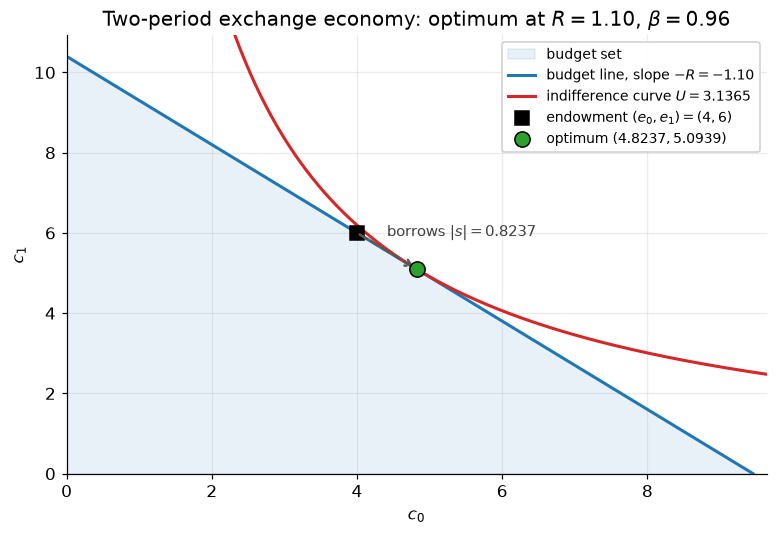

slope of budget line at optimum : -1.100000
slope of indiff. curve at optimum: -1.100000


In [8]:
# Budget line: c1 = R (W - c0), for c0 in [0, W]
c0_line = np.linspace(0.0, W, 500)
c1_line = R * (W - c0_line)

# Separate, economically relevant grid for the indifference curve so that the
# log-utility asymptote near c0 = 0 does not distort the axes.
Ubar = U(c0_star, c1_star, beta2)
c0_ic = np.linspace(0.35 * c0_star, 2.0 * c0_star, 600)
c1_ic = np.exp((Ubar - np.log(c0_ic)) / beta2)      # solve U(c0,c1)=Ubar for c1

fig, ax = plt.subplots()

ax.fill_between(c0_line, 0.0, c1_line, color="tab:blue", alpha=0.10,
                label="budget set")
ax.plot(c0_line, c1_line, color="tab:blue", lw=2,
        label=rf"budget line, slope $-R=-{R:.2f}$")
ax.plot(c0_ic, c1_ic, color="tab:red", lw=2,
        label=rf"indifference curve $U={Ubar:.4f}$")

ax.plot(e0, e1, "ks", ms=9, label=rf"endowment $(e_0,e_1)=({e0:.0f},{e1:.0f})$")
ax.plot(c0_star, c1_star, "o", color="tab:green", ms=10, mec="k", zorder=5,
        label=rf"optimum $({c0_star:.4f},{c1_star:.4f})$")

# borrowing arrow
ax.annotate("", xy=(c0_star, c1_star), xytext=(e0, e1),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=1.6, ls="--"))
ax.text(0.5 * (e0 + c0_star), 0.5 * (e1 + c1_star) + 0.35,
        rf"borrows $|s|={abs(s_star):.4f}$", color="0.25", fontsize=9.5)

ax.set_xlim(0, W * 1.02)
ax.set_ylim(0, R * W * 1.05)
ax.set_xlabel(r"$c_0$")
ax.set_ylabel(r"$c_1$")
ax.set_title(rf"Two-period exchange economy: optimum at $R={R:.2f}$, $\beta={beta2}$")
ax.legend(loc="upper right", framealpha=0.95, fontsize=9)
fig.tight_layout()
plt.show()

print(f"slope of budget line at optimum : {-R:.6f}")
print(f"slope of indiff. curve at optimum: {-c1_star / (beta2 * c0_star):.6f}")

**Answer (c).** The figure shows the standard picture. The budget line passes through the endowment
$(4,6)$ with slope $-R=-1.10$; the shaded triangle is the budget set. The optimum lies **to the
southeast of the endowment**, which is the geometric signature of borrowing: the consumer moves
resources from the future to the present. At the optimum the indifference curve is tangent to the
budget line — both slopes equal $-1.10$ — which is exactly the condition $MRS=R$.

### (d)
Solve the problem for 100 values of $R\in[0.8,1.5]$. Plot $c_0^*(R)$, $c_1^*(R)$, and saving. Explain income and substitution effects.

In [9]:
R_grid = np.linspace(0.8, 1.5, 100)

# Closed forms as functions of R
W_grid = e0 + e1 / R_grid
c0_of_R = W_grid / (1.0 + beta2)
c1_of_R = beta2 * R_grid * c0_of_R          # = beta*(R*e0 + e1)/(1+beta)
s_of_R = e0 - c0_of_R

# Numerical solution at every R, to confirm the closed form
c0_num_grid = np.empty_like(R_grid)
for m, Rm in enumerate(R_grid):
    Wm = e0 + e1 / Rm
    f = lambda x, Rm=Rm, Wm=Wm: (np.inf if (x <= 0 or Wm - x <= 0)
                                 else -U(x, Rm * (Wm - x), beta2))
    c0_num_grid[m] = minimize_scalar(f, bounds=(1e-10, Wm - 1e-10),
                                     method="bounded", options={"xatol": 1e-13}).x

print(f"max |analytical - numerical| over the 100 values of R: "
      f"{np.max(np.abs(c0_num_grid - c0_of_R)):.3e}")

R_hat_analytic = e1 / (beta2 * e0)
print(f"autarky rate  R_hat = e1/(beta*e0) = {R_hat_analytic:.6f}  (outside [0.8, 1.5])")

max |analytical - numerical| over the 100 values of R: 1.184e-07
autarky rate  R_hat = e1/(beta*e0) = 1.562500  (outside [0.8, 1.5])


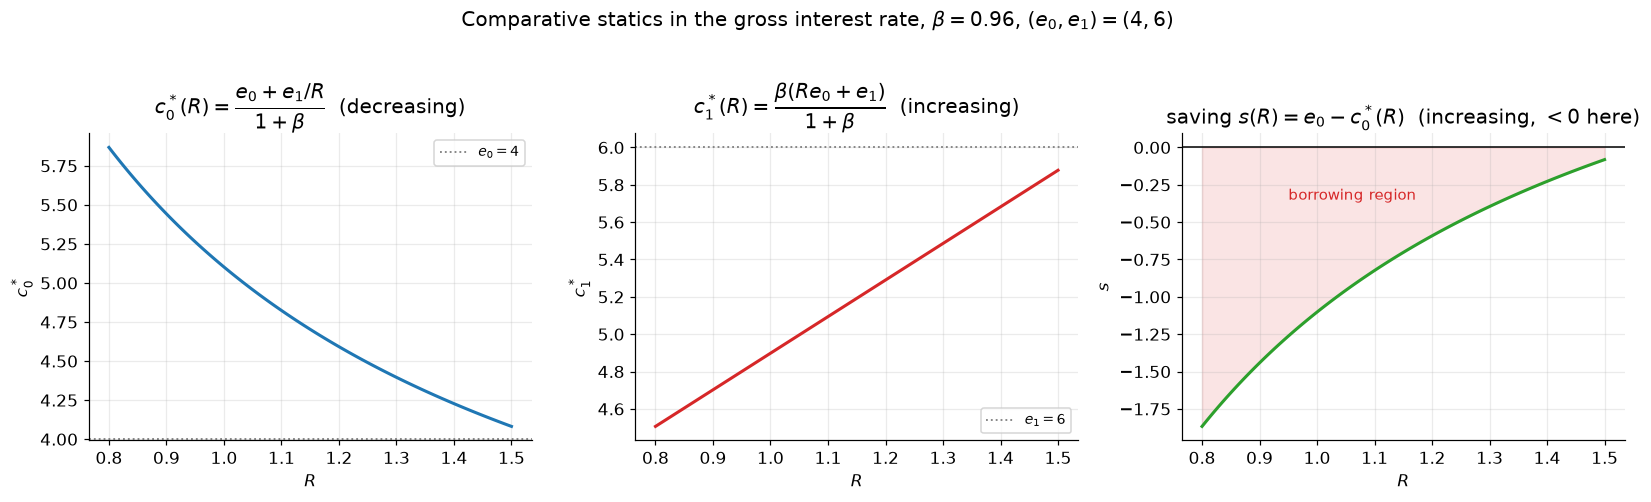

R = 0.80:  W = 11.5000,  c0* =  5.8673,  c1* =  4.5061,  s = -1.8673
R = 1.00:  W = 10.0000,  c0* =  5.1020,  c1* =  4.8980,  s = -1.1020
R = 1.10:  W =  9.4545,  c0* =  4.8237,  c1* =  5.0939,  s = -0.8237
R = 1.50:  W =  8.0000,  c0* =  4.0816,  c1* =  5.8776,  s = -0.0816


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15.0, 4.4))

ax[0].plot(R_grid, c0_of_R, lw=2, color="tab:blue")
ax[0].axhline(e0, color="0.5", ls=":", lw=1.2, label=r"$e_0=4$")
ax[0].set_title(r"$c_0^*(R)=\dfrac{e_0+e_1/R}{1+\beta}$  (decreasing)")
ax[0].set_ylabel(r"$c_0^*$")
ax[0].legend(fontsize=9)

ax[1].plot(R_grid, c1_of_R, lw=2, color="tab:red")
ax[1].axhline(e1, color="0.5", ls=":", lw=1.2, label=r"$e_1=6$")
ax[1].set_title(r"$c_1^*(R)=\dfrac{\beta(Re_0+e_1)}{1+\beta}$  (increasing)")
ax[1].set_ylabel(r"$c_1^*$")
ax[1].legend(fontsize=9)

ax[2].plot(R_grid, s_of_R, lw=2, color="tab:green")
ax[2].axhline(0.0, color="k", lw=1.0)
ax[2].fill_between(R_grid, s_of_R, 0, where=s_of_R < 0, color="tab:red", alpha=0.12)
ax[2].set_title(r"saving $s(R)=e_0-c_0^*(R)$  (increasing, $<0$ here)")
ax[2].set_ylabel(r"$s$")
ax[2].text(0.95, -0.35, "borrowing region", color="tab:red", fontsize=9.5)

for a in ax:
    a.set_xlabel(r"$R$")

fig.suptitle(r"Comparative statics in the gross interest rate, $\beta=0.96$, $(e_0,e_1)=(4,6)$",
             y=1.03)
fig.tight_layout()
plt.show()

for Rq in (0.8, 1.0, 1.10, 1.5):
    Wq = e0 + e1 / Rq
    c0q = Wq / (1 + beta2)
    print(f"R = {Rq:4.2f}:  W = {Wq:7.4f},  c0* = {c0q:7.4f},  "
          f"c1* = {beta2 * Rq * c0q:7.4f},  s = {e0 - c0q: 7.4f}")

**Answer (d).**

The closed forms are
$$
c_0^*(R)=\frac{e_0+e_1/R}{1+\beta},\qquad
c_1^*(R)=\frac{\beta\,(R e_0+e_1)}{1+\beta},\qquad
s(R)=e_0-c_0^*(R)=\frac{\beta e_0-e_1/R}{1+\beta},
$$
with derivatives
$$
\frac{dc_0^*}{dR}=-\frac{e_1}{(1+\beta)R^{2}}<0,\qquad
\frac{dc_1^*}{dR}=\frac{\beta e_0}{1+\beta}>0,\qquad
\frac{ds}{dR}=\frac{e_1}{(1+\beta)R^{2}}>0 .
$$
So $c_0^*$ falls monotonically ($5.8673$ at $R=0.8$ down to $4.0816$ at $R=1.5$), $c_1^*$ rises
monotonically ($4.5061$ to $5.8776$), and saving rises monotonically while remaining **negative
throughout $[0.8,1.5]$** — the agent is a borrower at every rate in this range. The numerical solver
matches the closed form to $\sim10^{-7}$ at all 100 grid points.

**Substitution effect.** A higher $R$ makes date-0 consumption relatively more expensive
($1$ unit of $c_0$ costs $R$ units of $c_1$). Holding utility fixed, the agent substitutes away from
$c_0$ toward $c_1$. With log utility the elasticity of intertemporal substitution is exactly $1$, so
this effect is strong: it always pushes $c_0$ down and $c_1$ up.

**Income (wealth) effect.** Present-value wealth $W(R)=e_0+e_1/R$ is *decreasing* in $R$ because the
endowment is future-weighted. Formally, differentiating the budget constraint at fixed consumption,
a change $dR$ slackens it by $s\,dR/R$ (using $c_1-e_1=Rs$), so the wealth effect carries the sign of
saving: it is negative for a **borrower** ($s<0$) and positive for a **lender** ($s>0$).

**Putting them together.** Here the agent borrows, so the two effects **reinforce** each other on
$c_0$: substitution says "consume less today because today is expensive," and the income effect says
"you are poorer because your debt service is more expensive." Hence $c_0^*$ falls unambiguously and
saving rises unambiguously — no ambiguity in this parameterization. For $c_1$, substitution pushes up
and the (negative) income effect pushes down, but with log utility substitution dominates and
$c_1^*$ rises.

**The contrast worth remembering.** For a *lender* ($s>0$) the two effects on $c_0$ have opposite
signs: the substitution effect lowers $c_0$ but the positive wealth effect raises it, so the sign of
$dc_0/dR$ is theoretically ambiguous and depends on the elasticity of intertemporal substitution. The
clean monotonicity we see here is a consequence of the future-heavy endowment, not a general theorem.
Note also that $c_1^*(R)$ is *linear* in $R$ and $c_0^*(R)$ is convex in $R$ — both artifacts of the
constant-savings-rate property of log utility.

### (e)
Find numerically and analytically the value $\widehat R$ at which the consumer chooses the endowment exactly. Interpret it.

**Analytical derivation.** The consumer chooses the endowment ($s=0$, i.e. $c_0=e_0$, $c_1=e_1$)
exactly when the MRS *evaluated at the endowment* equals the market rate:
$$
MRS(e_0,e_1)=\frac{e_1}{\beta e_0}=\widehat R .
$$
Equivalently, from $c_0^*=W/(1+\beta)=e_0$:
$$
e_0+\frac{e_1}{\widehat R}=(1+\beta)e_0
\;\Longrightarrow\;
\frac{e_1}{\widehat R}=\beta e_0
\;\Longrightarrow\;
\boxed{\widehat R=\frac{e_1}{\beta e_0}=\frac{6}{0.96\times 4}=1.5625 .}
$$

In [11]:
# Analytical
R_hat = e1 / (beta2 * e0)

# Numerical: root of s(R) = e0 - c0*(R)
def saving(Rv):
    Wv = e0 + e1 / Rv
    return e0 - Wv / (1.0 + beta2)

R_hat_brentq = brentq(saving, 0.5, 5.0, xtol=1e-14, rtol=8.9e-16)

# Numerical, fully "solve-the-problem-then-check" version (no closed form used)
def saving_numeric(Rv):
    Wv = e0 + e1 / Rv
    f = lambda x: (np.inf if (x <= 0 or Wv - x <= 0) else -U(x, Rv * (Wv - x), beta2))
    c0v = minimize_scalar(f, bounds=(1e-10, Wv - 1e-10), method="bounded",
                          options={"xatol": 1e-14}).x
    return e0 - c0v

R_hat_num = brentq(saving_numeric, 0.5, 5.0, xtol=1e-12)

print(f"R_hat analytical  = e1/(beta*e0) = {R_hat:.12f}")
print(f"R_hat brentq      (closed form)  = {R_hat_brentq:.12f}   error {abs(R_hat_brentq - R_hat):.2e}")
print(f"R_hat brentq      (full numeric) = {R_hat_num:.12f}   error {abs(R_hat_num - R_hat):.2e}")

Wh = e0 + e1 / R_hat
print(f"\nAt R_hat:  W = {Wh:.10f},  c0* = {Wh / (1 + beta2):.10f}  (= e0 = {e0}),  "
      f"c1* = {beta2 * R_hat * Wh / (1 + beta2):.10f}  (= e1 = {e1})")
print(f"           s  = {e0 - Wh / (1 + beta2):.3e}")
print(f"net interest rate r_hat = {R_hat - 1:.6f}")

R_hat analytical  = e1/(beta*e0) = 1.562500000000
R_hat brentq      (closed form)  = 1.562500000000   error 0.00e+00
R_hat brentq      (full numeric) = 1.562499981919   error 1.81e-08

At R_hat:  W = 7.8400000000,  c0* = 4.0000000000  (= e0 = 4.0),  c1* = 6.0000000000  (= e1 = 6.0)
           s  = 0.000e+00
net interest rate r_hat = 0.562500


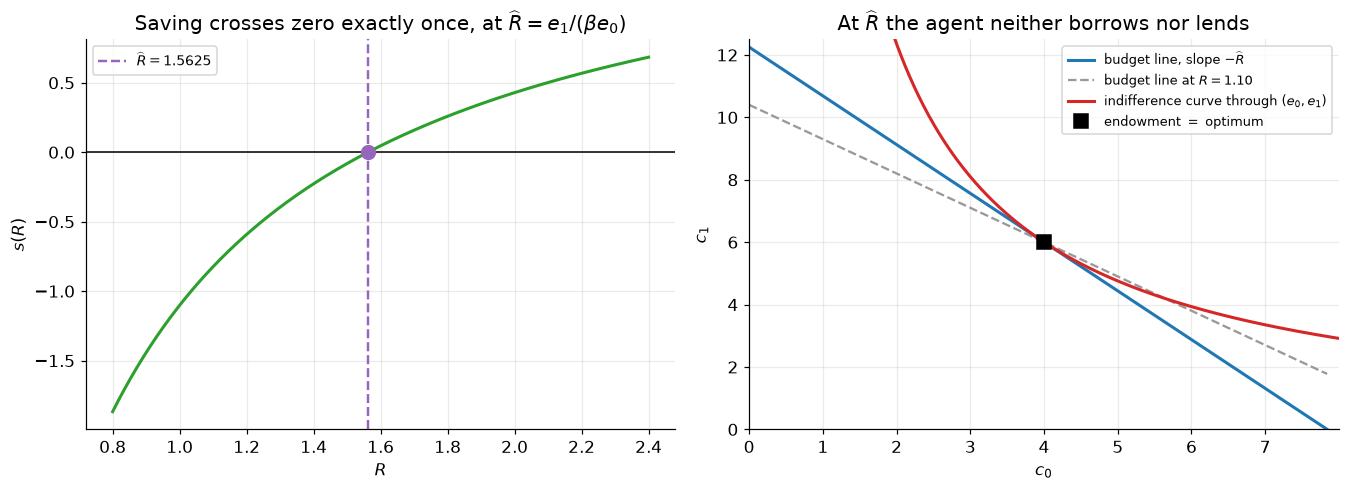

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.6))

Rw = np.linspace(0.8, 2.4, 400)
ax[0].plot(Rw, e0 - (e0 + e1 / Rw) / (1 + beta2), lw=2, color="tab:green")
ax[0].axhline(0, color="k", lw=1)
ax[0].axvline(R_hat, color="tab:purple", ls="--", lw=1.6,
              label=rf"$\widehat R={R_hat:.4f}$")
ax[0].plot(R_hat, 0, "o", color="tab:purple", ms=9, zorder=5)
ax[0].set_xlabel(r"$R$")
ax[0].set_ylabel(r"$s(R)$")
ax[0].set_title(r"Saving crosses zero exactly once, at $\widehat R=e_1/(\beta e_0)$")
ax[0].legend(fontsize=9)

# geometry: at R_hat the indifference curve is tangent to the budget line AT the endowment
Wh = e0 + e1 / R_hat
c0l = np.linspace(0, Wh, 300)
Ue = U(e0, e1, beta2)
c0i = np.linspace(0.45 * e0, 2.1 * e0, 500)
ax[1].plot(c0l, R_hat * (Wh - c0l), lw=2, color="tab:blue",
           label=rf"budget line, slope $-\widehat R$")
ax[1].plot(c0l, 1.10 * ((e0 + e1 / 1.10) - c0l), lw=1.5, ls="--", color="0.6",
           label=r"budget line at $R=1.10$")
ax[1].plot(c0i, np.exp((Ue - np.log(c0i)) / beta2), lw=2, color="tab:red",
           label=r"indifference curve through $(e_0,e_1)$")
ax[1].plot(e0, e1, "ks", ms=9, label=r"endowment $=$ optimum")
ax[1].set_xlim(0, Wh * 1.02)
ax[1].set_ylim(0, R_hat * Wh * 1.02)
ax[1].set_xlabel(r"$c_0$")
ax[1].set_ylabel(r"$c_1$")
ax[1].set_title(r"At $\widehat R$ the agent neither borrows nor lends")
ax[1].legend(fontsize=8.5, loc="upper right")

fig.tight_layout()
plt.show()

**Answer (e).** $\widehat R = e_1/(\beta e_0)=1.5625$, i.e. a net rate $\hat r = 56.25\%$. All three
methods agree: the closed form and `brentq` applied to the closed-form saving function match exactly,
and `brentq` applied to a saving function that *re-solves the optimization numerically* at every $R$
lands within $1.8\times10^{-8}$ (its accuracy is inherited from the inner minimizer, not the
root-finder). At $\widehat R$ the solver returns $c_0^*=4=e_0$ and $c_1^*=6=e_1$ with $s=0$ exactly.

**Interpretation.**

* $\widehat R$ is the **autarky rate**, or *shadow price of time* at the endowment. It is the interest
  rate at which the agent is exactly indifferent at the margin between borrowing and lending, so she
  chooses $s=0$ and consumes her endowment. Geometrically, it is the rate at which the budget line is
  tangent to the indifference curve *at the endowment point* (right panel).
* It decomposes into two forces: $\widehat R=\underbrace{1/\beta}_{\text{impatience}}\times
  \underbrace{e_1/e_0}_{\text{endowment growth}}$. Impatience ($\beta<1$) requires compensation for
  waiting; a growing endowment means the agent is already consumption-rich tomorrow, and
  diminishing marginal utility means she needs a *high* return to be willing to add still more to
  tomorrow. Here $1/0.96=1.0417$ and $e_1/e_0=1.5$, giving $1.5625$. This is precisely the
  consumption-Euler / Ramsey logic $R=\frac{1}{\beta}\frac{u'(c_0)}{u'(c_1)}$.
* It is a **sorting threshold**: for $R<\widehat R$ the market rate is below the agent's internal
  valuation of future goods, so she borrows ($s<0$); for $R>\widehat R$ she lends ($s>0$). Since
  $\widehat R=1.5625$ lies above the entire grid $[0.8,1.5]$ used in part (d), the agent borrows
  everywhere on that grid — consistent with what we found.
* **Equilibrium reading.** In a closed endowment economy with one (representative) agent and no
  production, market clearing requires $s=0$. Therefore $\widehat R$ *is* the general-equilibrium
  interest rate of the pure exchange economy: prices adjust so that the desired trade is zero when
  there is no one to trade with. Problem 5 does the analogous computation once a technology creates a
  genuine demand for funds.

---
# Problem 3. Intertemporal Production and the Planner

$$
y_0=10,\qquad
c_0+k_0=y_0,
$$
and
$$
c_1=f(k_0)=A k_0^\alpha,
\qquad
A=2.5,\quad \alpha=0.4.
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$

In [13]:
y0 = 10.0
Aprod = 2.5
alpha = 0.4
beta3 = 0.95


def f(k):
    """Production function mapping date-0 investment into date-1 output."""
    return Aprod * k ** alpha


def fprime(k):
    """Marginal product of capital."""
    return Aprod * alpha * k ** (alpha - 1.0)

### (a)
Write the planner's problem with all choice variables and constraints. Then reduce it to a one-variable problem in $k_0$.

**Answer (a).**

**The planner's problem in full.** Choose the allocation $(c_0,c_1,k_0)\in\mathbb{R}^3$ to
$$
\max_{c_0,\;c_1,\;k_0}\quad \log c_0+\beta\log c_1
$$
subject to
$$
\begin{aligned}
&\text{(date-0 resource constraint)} && c_0+k_0 \le y_0=10,\\
&\text{(date-1 resource constraint / technology)} && c_1 \le f(k_0)=Ak_0^{\alpha},\\
&\text{(non-negativity / feasibility)} && c_0>0,\; c_1>0,\; k_0\ge 0 .
\end{aligned}
$$

There are three choice variables and two resource constraints, hence one degree of freedom.

**Both constraints bind.** Utility is strictly increasing in $c_0$ and $c_1$, so free disposal is
never optimal: $c_0=y_0-k_0$ and $c_1=f(k_0)$. Also $k_0>0$ strictly, since $\log c_1\to-\infty$ as
$k_0\to0$, and $k_0<y_0$ strictly since $\log c_0\to-\infty$ as $k_0\to y_0$. So the solution is
interior and we may treat the constraints as equalities and ignore the inequality multipliers.

**Reduction to one variable.** Substituting,
$$
\boxed{\;\max_{0<k_0<y_0}\ \ G(k_0)\;\equiv\;\log(y_0-k_0)+\beta\log\!\big(Ak_0^{\alpha}\big)
\;=\;\log(y_0-k_0)+\alpha\beta\log k_0+\beta\log A. \;}
$$

Note that $\beta\log A$ is an additive constant and does not affect the optimal $k_0$: the *level* of
total factor productivity is irrelevant for the investment decision here, only the *curvature*
$\alpha$ matters. $G$ is strictly concave on $(0,y_0)$ since
$G''(k_0)=-\frac{1}{(y_0-k_0)^2}-\frac{\alpha\beta}{k_0^{2}}<0$, and $G\to-\infty$ at both endpoints,
so there is a **unique interior maximizer** characterized by $G'(k_0)=0$.

Interpretation: $k_0$ is the single margin the planner controls — how much of today's endowment to
*not eat* and instead put through the technology. The planner is simultaneously choosing a point on
the production possibility frontier and a consumption plan, because here they are the same choice.

### (b)
Derive the planner's first-order condition and show that $MRS=MRT$.

**Answer (b).**

**FOC.** Differentiating $G(k_0)=\log(y_0-k_0)+\beta\log f(k_0)$:
$$
G'(k_0)= -\frac{1}{y_0-k_0}+\beta\,\frac{f'(k_0)}{f(k_0)}=0
\quad\Longleftrightarrow\quad
\boxed{\ \frac{1}{c_0}=\beta\,\frac{f'(k_0)}{c_1}\ }
$$
which is the **Euler equation with the marginal product of capital as the return**:
$u'(c_0)=\beta\,u'(c_1)f'(k_0)$.

*Lagrangian route (same thing).* With
$\mathcal{L}=\log c_0+\beta\log c_1+\lambda_0(y_0-c_0-k_0)+\lambda_1(f(k_0)-c_1)$ the FOCs are
$1/c_0=\lambda_0$, $\beta/c_1=\lambda_1$, and $\lambda_0=\lambda_1 f'(k_0)$. The shadow prices
satisfy $\lambda_0/\lambda_1=f'(k_0)$: the planner's internal relative price of date-0 goods is the
marginal product of capital.

**$MRS=MRT$.** Rearranging the FOC,
$$
MRS_{0,1}\;=\;\frac{\partial U/\partial c_0}{\partial U/\partial c_1}
\;=\;\frac{1/c_0}{\beta/c_1}\;=\;\frac{c_1}{\beta c_0}\;=\;f'(k_0).
$$
On the other side, the production possibility frontier is
$c_1=F(c_0)\equiv f(y_0-c_0)$, so its slope is
$$
\frac{dc_1}{dc_0}=-f'(y_0-c_0)=-f'(k_0)
\quad\Longrightarrow\quad
MRT_{0,1}\;=\;-\frac{dc_1}{dc_0}\;=\;f'(k_0).
$$
Hence
$$
\boxed{\;MRS_{0,1}=\frac{c_1}{\beta c_0}=f'(k_0)=MRT_{0,1}.\;}
$$

**Economics.** $MRS$ is the *subjective* rate at which the household is willing to trade today's
consumption for tomorrow's; $MRT$ is the *technological* rate at which the economy is able to do so.
If $MRS>MRT$ the household values future goods more than the technology can deliver them — it should
invest less and eat more today; if $MRS<MRT$ it should invest more. Optimality equates the two: the
indifference curve is **tangent to the PPF**. This single tangency condition is the heart of the whole
problem set; in Problems 4 and 5 a price $R$ shows up in the middle of it, giving $MRS=R=MRT$.

### (c)
Solve analytically for $k_0^*,c_0^*,c_1^*$. Then solve numerically and compare.

**Analytical solution.** With $f(k)=Ak^{\alpha}$ we have $f'(k)/f(k)=\alpha/k$, so the FOC becomes
$$
\frac{1}{y_0-k_0}=\frac{\alpha\beta}{k_0}
\;\Longrightarrow\;
k_0=\alpha\beta\,(y_0-k_0)
\;\Longrightarrow\;
\boxed{k_0^*=\frac{\alpha\beta}{1+\alpha\beta}\,y_0 } .
$$
Then
$$
c_0^*=y_0-k_0^*=\frac{y_0}{1+\alpha\beta},\qquad
c_1^*=A\big(k_0^*\big)^{\alpha}.
$$
With $\alpha\beta=0.4\times0.95=0.38$ and $y_0=10$:
$$
k_0^*=\frac{3.8}{1.38}=2.753623,\qquad
c_0^*=\frac{10}{1.38}=7.246377,\qquad
c_1^*=2.5\,(2.7536232)^{0.4}=3.7488824 .
$$
Notice the **constant investment rate**: $k_0^*/y_0=\alpha\beta/(1+\alpha\beta)=27.54\%$, independent
of $A$ — the log-Cobb-Douglas hallmark.

In [14]:
def planner_objective(k):
    """Negative planner utility as a function of investment k only."""
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0.0) or np.any(k >= y0):
        return np.inf
    return -(np.log(y0 - k) + beta3 * np.log(f(k)))


# ---------------- Analytical ----------------
k_star = alpha * beta3 * y0 / (1.0 + alpha * beta3)
c0_p = y0 - k_star
c1_p = f(k_star)
U_p = U(c0_p, c1_p, beta3)

# ---------------- Numerical (bounded scalar minimization) ----------------
res3 = minimize_scalar(planner_objective, bounds=(1e-10, y0 - 1e-10),
                       method="bounded", options={"xatol": 1e-14})
k_num = res3.x
c0_num3, c1_num3 = y0 - k_num, f(k_num)

# ---------------- Numerical (root of the FOC) ----------------
foc = lambda k: -1.0 / (y0 - k) + beta3 * fprime(k) / f(k)
k_root = brentq(foc, 1e-8, y0 - 1e-8, xtol=1e-15, rtol=8.9e-16)

print(f"{'':<26}{'k0*':>14}{'c0*':>14}{'c1*':>14}{'U':>14}")
print(f"{'analytical':<26}{k_star:>14.10f}{c0_p:>14.10f}{c1_p:>14.10f}{U_p:>14.10f}")
print(f"{'numerical (minimize)':<26}{k_num:>14.10f}{c0_num3:>14.10f}{c1_num3:>14.10f}{-res3.fun:>14.10f}")
print(f"{'numerical (FOC root)':<26}{k_root:>14.10f}{y0 - k_root:>14.10f}{f(k_root):>14.10f}"
      f"{U(y0 - k_root, f(k_root), beta3):>14.10f}")

print(f"\n|k_minimize - k_analytic| = {abs(k_num - k_star):.3e}")
print(f"|k_brentq   - k_analytic| = {abs(k_root - k_star):.3e}")
print(f"investment rate k0*/y0    = {k_star / y0:.6%}   (= alpha*beta/(1+alpha*beta))")

MRS_p = c1_p / (beta3 * c0_p)
MRT_p = fprime(k_star)
print(f"\nMRS = c1*/(beta*c0*) = {MRS_p:.12f}")
print(f"MRT = f'(k0*)        = {MRT_p:.12f}")
print(f"MRS - MRT            = {MRS_p - MRT_p:.3e}")

                                     k0*           c0*           c1*             U
analytical                  2.7536231884  7.2463768116  3.7488823625  3.2358864648
numerical (minimize)        2.7536231466  7.2463768534  3.7488823397  3.2358864648
numerical (FOC root)        2.7536231884  7.2463768116  3.7488823625  3.2358864648

|k_minimize - k_analytic| = 4.183e-08
|k_brentq   - k_analytic| = 0.000e+00
investment rate k0*/y0    = 27.536232%   (= alpha*beta/(1+alpha*beta))

MRS = c1*/(beta*c0*) = 0.544574490556
MRT = f'(k0*)        = 0.544574490556
MRS - MRT            = 1.110e-16


**Answer (c).**
$$
k_0^*=2.7536232,\qquad c_0^*=7.2463768,\qquad c_1^*=3.7488824,\qquad U^*=3.2358865 .
$$
Three independent methods agree: the closed form, `minimize_scalar` on the reduced one-variable
objective, and `brentq` on the first-order condition. Discrepancies are $\sim4\times10^{-8}$ for the
optimizer (its tolerance is on $k$, and the objective is flat to second order at the optimum, so this
is the expected accuracy) and exactly $0$ for the root-finder, which exploits the sharper
information in $G'$. The optimality condition holds to machine precision:
$MRS=MRT=f'(k_0^*)=0.5445745$, with $|MRS-MRT|=1.1\times10^{-16}$.

That $f'(k_0^*)<1$ (a *negative* net interest rate $r^*=-45.54\%$) is not an error: the endowment
$y_0=10$ is large relative to the productivity of the technology, so the economy is capital-abundant
at the optimum and the marginal product of the last unit invested is low. It will reappear in Problem
4 as the equilibrium gross interest rate.

### (d)
Plot the PPF, planner optimum, indifference curve, and supporting tangent. Report the slopes at the optimum.

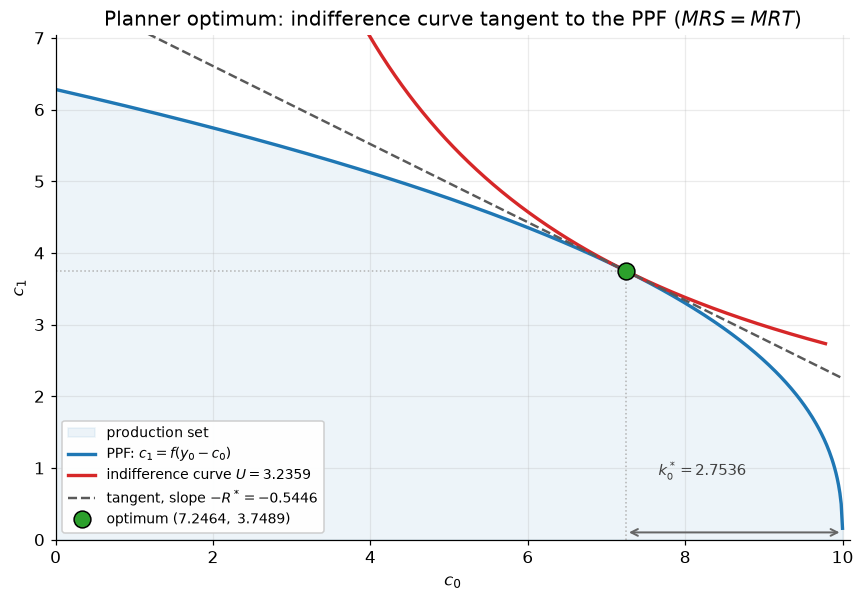

slope of PPF at optimum        (analytic) = -0.544574490556
slope of PPF at optimum  (finite diff.)   = -0.544574490835
slope of indiff. curve at opt. (analytic) = -0.544574490556
slope of indiff. curve   (finite diff.)   = -0.544574490613

tangency error |slope_PPF - slope_IC|     = 1.110e-16
implied gross rate  R* = 0.5445744906,  net rate r* = -0.4554255094


In [15]:
# PPF grid: c1 = f(y0 - c0)
c0_vals = np.linspace(0.001, y0 - 0.001, 600)
ppf = f(y0 - c0_vals)

# Indifference curve through the optimum, on a separate, economically relevant range
# so the log-utility asymptote near c0 = 0 does not distort the graph.
c0_ic3 = np.linspace(0.55 * c0_p, min(1.35 * c0_p, y0 - 1e-6), 600)
c1_ic3 = np.exp((U_p - np.log(c0_ic3)) / beta3)

# Supporting tangent line (the price line): c1 = c1* - R*(c0 - c0*)
R_tan = fprime(k_star)
tangent = c1_p - R_tan * (c0_vals - c0_p)

fig, ax = plt.subplots(figsize=(8.0, 5.6))

ax.fill_between(c0_vals, 0, ppf, color="tab:blue", alpha=0.08, label="production set")
ax.plot(c0_vals, ppf, lw=2.2, color="tab:blue", label=r"PPF: $c_1=f(y_0-c_0)$")
ax.plot(c0_ic3, c1_ic3, lw=2.2, color="tab:red",
        label=rf"indifference curve $U={U_p:.4f}$")
ax.plot(c0_vals, tangent, lw=1.6, ls="--", color="0.35",
        label=rf"tangent, slope $-R^*=-{R_tan:.4f}$")
ax.plot(c0_p, c1_p, "o", color="tab:green", ms=11, mec="k", zorder=6,
        label=rf"optimum $({c0_p:.4f},\;{c1_p:.4f})$")
ax.vlines(c0_p, 0, c1_p, color="0.7", lw=1, ls=":")
ax.hlines(c1_p, 0, c0_p, color="0.7", lw=1, ls=":")
ax.annotate(rf"$k_0^*={k_star:.4f}$", xy=(c0_p + 0.4 * k_star, 0.16),
            xytext=(c0_p + 0.15 * k_star, 0.9), fontsize=9.5, color="0.25")
ax.annotate("", xy=(y0, 0.1), xytext=(c0_p, 0.1),
            arrowprops=dict(arrowstyle="<->", color="0.4", lw=1.3))

ax.set_xlim(0, y0 * 1.01)
ax.set_ylim(0, max(ppf) * 1.12)
ax.set_xlabel(r"$c_0$")
ax.set_ylabel(r"$c_1$")
ax.set_title(r"Planner optimum: indifference curve tangent to the PPF ($MRS=MRT$)")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
fig.tight_layout()
plt.show()

# ---------------- Slopes at the optimum ----------------
slope_ppf = -fprime(k_star)
slope_ic = -c1_p / (beta3 * c0_p)

h = 1e-6
slope_ppf_fd = (f(y0 - (c0_p + h)) - f(y0 - (c0_p - h))) / (2 * h)
slope_ic_fd = (np.exp((U_p - np.log(c0_p + h)) / beta3)
               - np.exp((U_p - np.log(c0_p - h)) / beta3)) / (2 * h)

print(f"slope of PPF at optimum        (analytic) = {slope_ppf:.12f}")
print(f"slope of PPF at optimum  (finite diff.)   = {slope_ppf_fd:.12f}")
print(f"slope of indiff. curve at opt. (analytic) = {slope_ic:.12f}")
print(f"slope of indiff. curve   (finite diff.)   = {slope_ic_fd:.12f}")
print(f"\ntangency error |slope_PPF - slope_IC|     = {abs(slope_ppf - slope_ic):.3e}")
print(f"implied gross rate  R* = {-slope_ppf:.10f},  net rate r* = {-slope_ppf - 1:.10f}")

**Answer (d).** At the optimum $(c_0^*,c_1^*)=(7.2464,\,3.7489)$:

$$
\text{slope of PPF}=-f'(k_0^*)=-0.5445745,\qquad
\text{slope of indifference curve}=-\frac{c_1^*}{\beta c_0^*}=-0.5445745 .
$$

They coincide to machine precision, $1.1\times10^{-16}$ (and the finite-difference slopes confirm the
analytics to $\sim10^{-10}$). The single dashed line is simultaneously tangent to the PPF and to the indifference
curve — it is the **supporting price line**, and its slope $-R^*$ is the shadow price that will be
decentralized as the market interest rate in Problem 4. The PPF is strictly concave (because
$\alpha<1$ implies diminishing returns) and the indifference curve is strictly convex, so the tangency
point is unique; a supporting hyperplane exists at exactly one point. The horizontal arrow measures
$k_0^*=2.7536$, the resources withheld from date-0 consumption.

### (e)
Vary $\beta$ from 0.50 to 1.00. Compute and plot optimal investment $k_0^*(\beta)$. Explain the economics and discuss monotonicity.

max |analytical - numerical| over 100 betas: 1.434e-07


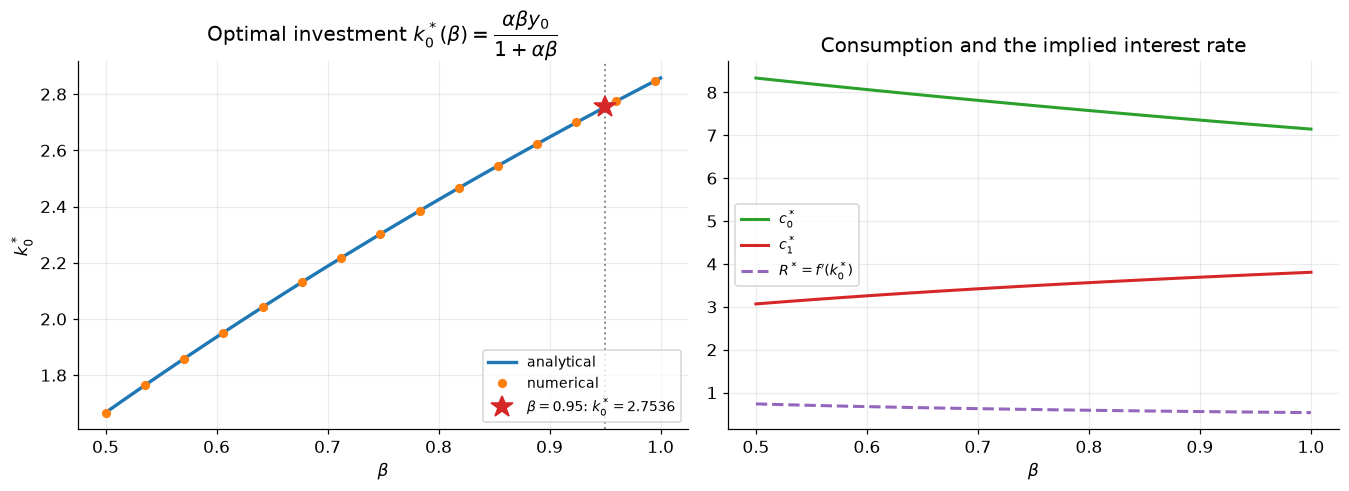


  beta         k0*         c0*         c1*    k0*/y0    R*=f(k*)
  0.50    1.666667    8.333333    3.066758    0.1667    0.736022
  0.60    1.935484    8.064516    3.255786    0.1935    0.672862
  0.70    2.187500    7.812500    3.419158    0.2188    0.625218
  0.80    2.424242    7.575758    3.562628    0.2424    0.587834
  0.90    2.647059    7.352941    3.690162    0.2647    0.557624
  0.95    2.753623    7.246377    3.748882    0.2754    0.544574
  1.00    2.857143    7.142857    3.804633    0.2857    0.532649

dk*/dbeta ranges from 2.777778 (at beta=0.5) to 2.040816 (at beta=1) > 0


In [16]:
beta_grid = np.linspace(0.50, 1.00, 100)

# Analytical
k_of_beta = alpha * beta_grid * y0 / (1.0 + alpha * beta_grid)

# Numerical, solved independently at each beta
k_of_beta_num = np.empty_like(beta_grid)
for m, b in enumerate(beta_grid):
    g = lambda k, b=b: (np.inf if (k <= 0 or k >= y0)
                        else -(np.log(y0 - k) + b * np.log(f(k))))
    k_of_beta_num[m] = minimize_scalar(g, bounds=(1e-10, y0 - 1e-10),
                                       method="bounded", options={"xatol": 1e-13}).x

print(f"max |analytical - numerical| over 100 betas: "
      f"{np.max(np.abs(k_of_beta - k_of_beta_num)):.3e}")

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.6))

ax[0].plot(beta_grid, k_of_beta, lw=2.2, color="tab:blue", label="analytical")
ax[0].plot(beta_grid[::7], k_of_beta_num[::7], "o", ms=5, color="tab:orange",
           label="numerical")
ax[0].axvline(beta3, color="0.55", ls=":", lw=1.3)
ax[0].plot(beta3, k_star, "*", color="tab:red", ms=15, zorder=5,
           label=rf"$\beta={beta3}$: $k_0^*={k_star:.4f}$")
ax[0].set_xlabel(r"$\beta$")
ax[0].set_ylabel(r"$k_0^*$")
ax[0].set_title(r"Optimal investment $k_0^*(\beta)=\dfrac{\alpha\beta y_0}{1+\alpha\beta}$")
ax[0].legend(fontsize=9, loc="lower right")

ax[1].plot(beta_grid, y0 - k_of_beta, lw=2, color="tab:green", label=r"$c_0^*$")
ax[1].plot(beta_grid, f(k_of_beta), lw=2, color="tab:red", label=r"$c_1^*$")
ax[1].plot(beta_grid, fprime(k_of_beta), lw=2, ls="--", color="tab:purple",
           label=r"$R^*=f'(k_0^*)$")
ax[1].set_xlabel(r"$\beta$")
ax[1].set_title(r"Consumption and the implied interest rate")
ax[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"\n{'beta':>6}{'k0*':>12}{'c0*':>12}{'c1*':>12}{'k0*/y0':>10}{'R*=f(k*)':>12}")
for b in (0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 1.00):
    kb = alpha * b * y0 / (1 + alpha * b)
    print(f"{b:>6.2f}{kb:>12.6f}{y0 - kb:>12.6f}{f(kb):>12.6f}"
          f"{kb / y0:>10.4f}{fprime(kb):>12.6f}")

dk = alpha * y0 / (1 + alpha * beta_grid) ** 2
print(f"\ndk*/dbeta ranges from {dk.max():.6f} (at beta=0.5) to {dk.min():.6f} (at beta=1) > 0")

**Answer (e).**

$$
k_0^*(\beta)=\frac{\alpha\beta\,y_0}{1+\alpha\beta}
\qquad\Longrightarrow\qquad
\frac{dk_0^*}{d\beta}=\frac{\alpha y_0}{(1+\alpha\beta)^{2}}>0 ,
\qquad
\frac{d^{2}k_0^*}{d\beta^{2}}=-\frac{2\alpha^{2}y_0}{(1+\alpha\beta)^{3}}<0 .
$$

Investment rises from $k_0^*=1.6667$ at $\beta=0.50$ to $k_0^*=2.8571$ at $\beta=1.00$ — a range of
$16.7\%$ to $28.6\%$ of $y_0$. The numerical solution matches the closed form at all 100 grid points
to $\sim10^{-7}$.

**Monotonicity.** $k_0^*$ is **strictly increasing** in $\beta$, and this is global and unambiguous
here. The reason is transparent in the reduced objective
$G(k)=\log(y_0-k)+\alpha\beta\log k+\beta\log A$: $\partial^2 G/\partial k\partial\beta=\alpha/k>0$,
so the objective is *supermodular* in $(k,\beta)$ and Topkis's monotone-comparative-statics theorem
delivers monotonicity without any computation. Note it is also **strictly concave** in $\beta$:
increases in patience have diminishing effects on investment because diminishing returns
($\alpha<1$) choke off the extra capital, and because $k_0^*<y_0\alpha/(1+\alpha)$ is bounded above
by $2.857$ even as $\beta\to1$.

**Economics.**

* $\beta$ measures **patience**. A higher $\beta$ raises the weight on $\log c_1$, so the planner is
  willing to sacrifice more current consumption for future output. Investment is the only vehicle for
  intertemporal transfer, so it rises.
* Equivalently, a higher $\beta$ *lowers* the required return: rewriting the FOC as
  $f'(k_0^*)=\frac{c_1^*}{\beta c_0^*}$, a larger $\beta$ shrinks the right-hand side, and since
  $f'$ is decreasing the solution $k_0^*$ must be larger. The purple dashed line in the right panel
  shows $R^*=f'(k_0^*)$ falling from $0.7360$ at $\beta=0.5$ to $0.5326$ at $\beta=1$: **patient
  economies have low interest rates and high capital**. This is the two-period ancestor of the
  neoclassical growth model's steady state $f'(k)=1/\beta$.
* $c_0^*$ falls and $c_1^*$ rises with $\beta$: the whole consumption profile tilts toward the future.
* **The knife-edge at $\beta=1$**: even with no discounting the planner does not invest everything,
  because $\log$ utility makes $c_0=0$ infinitely costly. Investment stays interior at $28.6\%$ of
  output — preferences, not just impatience, limit capital accumulation.
* $A$ is absent from $k_0^*$. Under log utility and Cobb–Douglas technology the income and
  substitution effects of a productivity increase exactly offset in the *investment rate*; only
  $\alpha$ (the curvature of the technology) and $\beta$ (patience) matter.

---
# Problem 4. Decentralizing the Planner's Allocation

Now production is carried out by a competitive firm and consumption is chosen by a competitive consumer.

**Setup and timing.** There are three agents/objects: a representative **household** that owns the
date-0 endowment $y_0=10$ and owns the firm, a representative **firm** with technology $f$, and a
**credit market** with gross real rate $R$. Both take $R$ as given.

* Date 0: the household receives $y_0$, consumes $c_0$, and lends $s=y_0-c_0$. The firm borrows $k_0$
  and invests it.
* Date 1: the firm produces $f(k_0)$, repays $Rk_0$ to the household, and distributes the residual
  $D_1=f(k_0)-Rk_0$ as a dividend to its owner, the household. The household consumes
  $c_1=Rs+D_1$.
* Market clearing in the credit market: $\;s=k_0$.

### (a)
Derive the firm's first-order condition from its present-value profit-maximization problem.

**Answer (a).**

The firm borrows $k_0$ at date 0 and sells output $f(k_0)$ at date 1. Discounting date-1 goods by
$1/R$, present-value profit is
$$
\pi(k_0)\;=\;-k_0+\frac{f(k_0)}{R}\;=\;-k_0+\frac{Ak_0^{\alpha}}{R}.
$$
(Equivalently the firm maximizes date-1 profit $f(k_0)-Rk_0$; the two problems have the same
solution because they differ by the positive factor $R$.)

The problem $\max_{k_0\ge 0}\pi(k_0)$ is strictly concave for $\alpha<1$, with
$\pi'(k)\to+\infty$ as $k\to0^+$ and $\pi'(k)\to-1$ as $k\to\infty$, so there is a unique interior
solution given by
$$
\pi'(k_0)=-1+\frac{f'(k_0)}{R}=0
\qquad\Longleftrightarrow\qquad
\boxed{\;f'(k_0)=R\;}
\qquad\Longleftrightarrow\qquad
A\alpha k_0^{\alpha-1}=R .
$$

**Capital demand.** Inverting,
$$
k^{d}(R)=\left(\frac{A\alpha}{R}\right)^{\frac{1}{1-\alpha}},
\qquad
\frac{dk^{d}}{dR}=-\frac{1}{1-\alpha}\frac{k^{d}}{R}<0 ,
$$
a downward-sloping demand for funds with constant elasticity $-1/(1-\alpha)=-5/3$.

**Economics.** "Invest until the marginal product of capital equals the cost of funds." Because $f$
exhibits diminishing returns, $f'$ is decreasing and the condition pins down a unique $k_0$ for each
$R$. Maximum profit is
$$
\pi\big(k^d(R)\big)=-k^d+\frac{f(k^d)}{R}
=-k^d+\frac{f(k^d)}{f'(k^d)}=-k^d+\frac{k^d}{\alpha}=\frac{1-\alpha}{\alpha}\,k^{d}(R)>0,
$$
using $f(k)/f'(k)=k/\alpha$ for Cobb–Douglas. Profits are strictly positive because $f$ has
*decreasing* returns to scale in the single input $k$ — economically, they are the return to the
fixed factor implicit in $A$, and they accrue to the household as the firm's owner. Note this is why
we must be careful to include $\pi$ in household wealth: otherwise the decentralized allocation would
not replicate the planner's.

### (b)
Using the planner's $k_0^*$, calculate $R^*=f'(k_0^*)$ and $r^*=R^*-1$.

In [17]:
R_ast = fprime(k_star)
r_ast = R_ast - 1.0

print(f"k0*            = {k_star:.10f}")
print(f"R* = f'(k0*)   = A*alpha*k^(alpha-1) = {R_ast:.10f}")
print(f"r* = R* - 1    = {r_ast:.10f}   ({r_ast:.4%})")

# Closed form: R* = A*alpha*((1+alpha*beta)/(alpha*beta*y0))**(1-alpha)
R_ast_cf = Aprod * alpha * ((1 + alpha * beta3) / (alpha * beta3 * y0)) ** (1 - alpha)
print(f"closed form    = {R_ast_cf:.10f}   (difference {abs(R_ast_cf - R_ast):.2e})")

# Consistency: the firm's capital demand at R* must return k0*
k_demand_at_Rast = (Aprod * alpha / R_ast) ** (1.0 / (1.0 - alpha))
print(f"\nk^d(R*)        = {k_demand_at_Rast:.10f}   vs  k0* = {k_star:.10f}"
      f"   (difference {abs(k_demand_at_Rast - k_star):.2e})")
print(f"MRS at planner allocation = {c1_p / (beta3 * c0_p):.10f}  == R*")

k0*            = 2.7536231884
R* = f'(k0*)   = A*alpha*k^(alpha-1) = 0.5445744906
r* = R* - 1    = -0.4554255094   (-45.5426%)
closed form    = 0.5445744906   (difference 0.00e+00)

k^d(R*)        = 2.7536231884   vs  k0* = 2.7536231884   (difference 4.44e-16)
MRS at planner allocation = 0.5445744906  == R*


**Answer (b).**
$$
R^*=f'(k_0^*)=A\alpha (k_0^*)^{\alpha-1}=2.5(0.4)(2.7536232)^{-0.6}=\boxed{0.5445745},
\qquad
r^*=R^*-1=\boxed{-0.4554255}\;(-45.54\%).
$$
Equivalently, in closed form,
$$
R^*=A\alpha\left(\frac{1+\alpha\beta}{\alpha\beta y_0}\right)^{1-\alpha}.
$$
The firm's capital demand evaluated at this rate returns exactly $k^d(R^*)=k_0^*$, as it must by
construction. A negative *net* rate is perfectly coherent in a two-period economy with a large
date-0 endowment and a low-productivity technology: storing goods through the technology destroys
value at the margin, but the household still invests because $\log$ utility makes $c_1=0$
unacceptable. The price of a date-1 good in date-0 units is $1/R^*=1.8363>1$: future goods are
*expensive*, which is another way of saying the economy is desperate to move resources forward in
time.

### (c)
Take $R^*$ as given. Compute firm profits, household wealth, and the household's optimal consumption bundle. Show that it coincides with the planner allocation.

**Household problem.** Taking $R$ and the dividend as given, the household solves
$$
\max_{c_0,c_1}\ \log c_0+\beta\log c_1
\quad\text{s.t.}\quad
c_0+\frac{c_1}{R}\;=\;y_0+\pi \;\equiv\; W^{h},
$$
where $\pi=D_1/R$ is the present value of the firm's dividend. By part 2(b) the solution is
$c_0=\dfrac{W^h}{1+\beta}$, $c_1=\beta R\,c_0$.

In [18]:
# 1 -------- firm behaviour and profit at R*
k_firm = (Aprod * alpha / R_ast) ** (1.0 / (1.0 - alpha))       # firm's own choice
profit_pv = -k_firm + f(k_firm) / R_ast                          # present-value profit
dividend_1 = f(k_firm) - R_ast * k_firm                          # date-1 dividend
print("--- firm ---")
print(f"k^d(R*)                       = {k_firm:.10f}")
print(f"output f(k)                   = {f(k_firm):.10f}")
print(f"debt repayment R*k            = {R_ast * k_firm:.10f}")
print(f"date-1 dividend D1 = f - R*k  = {dividend_1:.10f}")
print(f"PV profit  pi = D1/R*         = {profit_pv:.10f}"
      f"   (check (1-a)/a * k = {(1 - alpha) / alpha * k_firm:.10f})")

# 2 -------- household wealth, including ownership of the firm
W_h = y0 + profit_pv
print("\n--- household wealth ---")
print(f"endowment y0                  = {y0:.10f}")
print(f"+ PV of firm profit           = {profit_pv:.10f}")
print(f"= present-value wealth W^h    = {W_h:.10f}")

# 3 -------- household optimum (analytical, then re-solved numerically)
c0_h = W_h / (1.0 + beta3)
c1_h = beta3 * R_ast * c0_h
s_h = y0 - c0_h

obj_h = lambda x: (np.inf if (x <= 0 or W_h - x <= 0)
                   else -U(x, R_ast * (W_h - x), beta3))
c0_h_num = minimize_scalar(obj_h, bounds=(1e-10, W_h - 1e-10), method="bounded",
                           options={"xatol": 1e-14}).x

print("\n--- household optimum ---")
print(f"c0 (analytic) = {c0_h:.10f}      c0 (numeric) = {c0_h_num:.10f}")
print(f"c1 (analytic) = {c1_h:.10f}")
print(f"saving s = y0 - c0 = {s_h:.10f}")

# 4 -------- comparison with the planner, and market clearing
print("\n--- decentralized vs planner ---")
print(f"{'':<10}{'market':>16}{'planner':>16}{'|difference|':>16}")
for lab, mk, pl in (("c0", c0_h, c0_p), ("c1", c1_h, c1_p), ("k0", k_firm, k_star),
                    ("U", U(c0_h, c1_h, beta3), U_p)):
    print(f"{lab:<10}{mk:>16.10f}{pl:>16.10f}{abs(mk - pl):>16.3e}")

print("\n--- market clearing ---")
print(f"household saving s  = {s_h:.10f}")
print(f"firm investment k   = {k_firm:.10f}")
print(f"credit market gap   = {s_h - k_firm:.3e}")
print(f"goods market date 0: y0 - c0 - k = {y0 - c0_h - k_firm:.3e}")
print(f"goods market date 1: f(k) - c1   = {f(k_firm) - c1_h:.3e}")

--- firm ---
k^d(R*)                       = 2.7536231884
output f(k)                   = 3.7488823625
debt repayment R*k            = 1.4995529450
date-1 dividend D1 = f - R*k  = 2.2493294175
PV profit  pi = D1/R*         = 4.1304347826   (check (1-a)/a * k = 4.1304347826)

--- household wealth ---
endowment y0                  = 10.0000000000
+ PV of firm profit           = 4.1304347826
= present-value wealth W^h    = 14.1304347826

--- household optimum ---
c0 (analytic) = 7.2463768116      c0 (numeric) = 7.2463767058
c1 (analytic) = 3.7488823625
saving s = y0 - c0 = 2.7536231884

--- decentralized vs planner ---
                    market         planner    |difference|
c0            7.2463768116    7.2463768116       0.000e+00
c1            3.7488823625    3.7488823625       8.882e-16
k0            2.7536231884    2.7536231884       4.441e-16
U             3.2358864648    3.2358864648       0.000e+00

--- market clearing ---
household saving s  = 2.7536231884
firm investment k   =

**Answer (c).** At $R^*=0.5445745$:

| object | value |
|---|---|
| firm investment $k^d(R^*)$ | $2.7536232$ |
| output $f(k)$ | $3.7488824$ |
| debt repayment $R^*k$ | $1.4995529$ |
| date-1 dividend $D_1=f(k)-R^*k$ | $2.2493294$ |
| PV profit $\pi=D_1/R^*=\frac{1-\alpha}{\alpha}k$ | $4.1304348$ |
| household wealth $W^h=y_0+\pi$ | $14.1304348$ |
| $c_0=W^h/(1+\beta)$ | $7.2463768$ |
| $c_1=\beta R^* c_0$ | $3.7488824$ |
| saving $s=y_0-c_0$ | $2.7536232$ |

**The allocation is identical to the planner's**, to machine precision, and all markets clear:
$s=k$, $y_0-c_0-k=0$, and $f(k)-c_1=0$.

**Why it works algebraically.** Household wealth is
$$
W^h=y_0+\frac{1-\alpha}{\alpha}k_0^*
=y_0+\frac{1-\alpha}{\alpha}\cdot\frac{\alpha\beta y_0}{1+\alpha\beta}
=y_0\,\frac{1+\alpha\beta+\beta-\alpha\beta}{1+\alpha\beta}
=y_0\,\frac{1+\beta}{1+\alpha\beta},
$$
so
$$
c_0=\frac{W^h}{1+\beta}=\frac{y_0}{1+\alpha\beta}=c_0^* .\qquad\checkmark
$$
The cancellation is not a coincidence: it is the Second Welfare Theorem at work. The planner's shadow
price $\lambda_0/\lambda_1=f'(k_0^*)$ is exactly the price at which the *separate* optimizations of
household and firm, plus the requirement that all income (including profit) be returned to the
household, reproduce the joint optimum.

**Why it works economically.** The planner solves one problem with one tangency condition
$MRS=f'(k_0)$. The market splits this into two: the firm equates $f'(k_0)=R$ (technology to price) and
the household equates $MRS=R$ (preferences to price). Because both face the *same* $R$, the two
halves chain together into $MRS=R=MRT$ — the planner's condition. The price system is the messenger
that carries the planner's information without the planner.

### (d)
Verify numerically that $MRS=R^*=MRT$, and report numerical errors.

In [19]:
MRS_m = c1_h / (beta3 * c0_h)                  # household: (dU/dc0)/(dU/dc1)
MRT_m = fprime(k_firm)                         # technology: -dc1/dc0 along the PPF

# finite-difference versions, computed directly from the primitives
h = 1e-6
U_at = U(c0_h, c1_h, beta3)
c1_up = np.exp((U_at - np.log(c0_h + h)) / beta3)
c1_dn = np.exp((U_at - np.log(c0_h - h)) / beta3)
MRS_fd = -(c1_up - c1_dn) / (2 * h)
MRT_fd = -(f(y0 - (c0_h + h)) - f(y0 - (c0_h - h))) / (2 * h)

print("            MRS = R* = MRT   verification")
print("-" * 60)
print(f"MRS  (analytic, c1/(beta c0))     = {MRS_m:.14f}")
print(f"MRS  (finite difference on IC)    = {MRS_fd:.14f}")
print(f"R*   (market price)               = {R_ast:.14f}")
print(f"MRT  (analytic, f'(k))            = {MRT_m:.14f}")
print(f"MRT  (finite difference on PPF)   = {MRT_fd:.14f}")
print("-" * 60)
print("errors")
print(f"|MRS - R*|                        = {abs(MRS_m - R_ast):.3e}")
print(f"|MRT - R*|                        = {abs(MRT_m - R_ast):.3e}")
print(f"|MRS - MRT|                       = {abs(MRS_m - MRT_m):.3e}")
print(f"|MRS_fd - MRS|  (truncation)      = {abs(MRS_fd - MRS_m):.3e}")
print(f"|MRT_fd - MRT|  (truncation)      = {abs(MRT_fd - MRT_m):.3e}")
print("\nresidual optimality / feasibility conditions")
print(f"Euler:  1/c0 - beta*R*/c1         = {1 / c0_h - beta3 * R_ast / c1_h:.3e}")
print(f"firm :  f'(k) - R*                = {fprime(k_firm) - R_ast:.3e}")
print(f"budget: c0 + c1/R* - W^h          = {c0_h + c1_h / R_ast - W_h:.3e}")
print(f"clear:  s - k                     = {s_h - k_firm:.3e}")
print(f"alloc:  |c0 - c0_planner|         = {abs(c0_h - c0_p):.3e}")
print(f"alloc:  |c1 - c1_planner|         = {abs(c1_h - c1_p):.3e}")
print(f"utility gap U_market - U_planner  = {U(c0_h, c1_h, beta3) - U_p:.3e}")

            MRS = R* = MRT   verification
------------------------------------------------------------
MRS  (analytic, c1/(beta c0))     = 0.54457449055565
MRS  (finite difference on IC)    = 0.54457449061296
R*   (market price)               = 0.54457449055565
MRT  (analytic, f'(k))            = 0.54457449055565
MRT  (finite difference on PPF)   = 0.54457449083500
------------------------------------------------------------
errors
|MRS - R*|                        = 0.000e+00
|MRT - R*|                        = 0.000e+00
|MRS - MRT|                       = 0.000e+00
|MRS_fd - MRS|  (truncation)      = 5.731e-11
|MRT_fd - MRT|  (truncation)      = 2.794e-10

residual optimality / feasibility conditions
Euler:  1/c0 - beta*R*/c1         = 0.000e+00
firm :  f'(k) - R*                = 0.000e+00
budget: c0 + c1/R* - W^h          = 0.000e+00
clear:  s - k                     = 0.000e+00
alloc:  |c0 - c0_planner|         = 0.000e+00
alloc:  |c1 - c1_planner|         = 8.882e-16
utility gap 

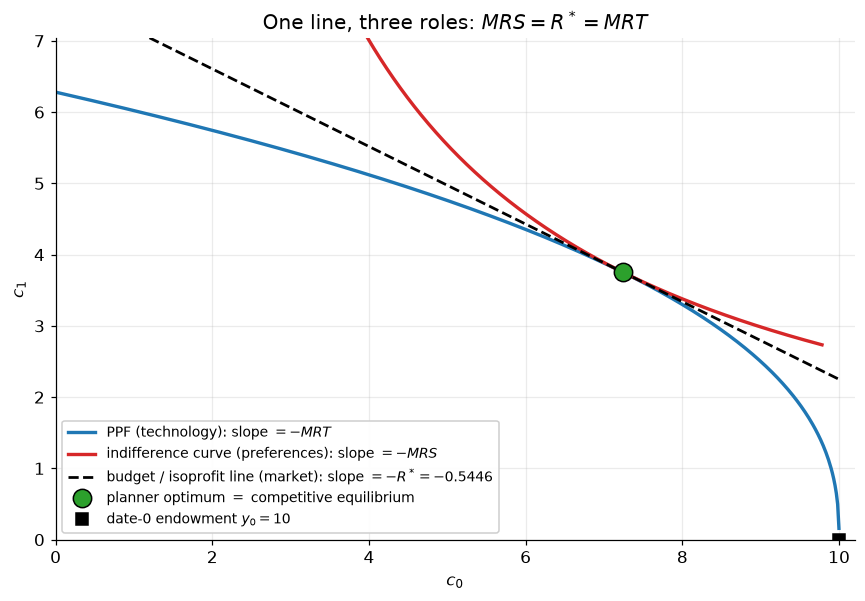

In [20]:
fig, ax = plt.subplots(figsize=(8.0, 5.6))

ax.plot(c0_vals, ppf, lw=2.2, color="tab:blue", label=r"PPF (technology): slope $=-MRT$")
ax.plot(c0_ic3, c1_ic3, lw=2.2, color="tab:red",
        label=r"indifference curve (preferences): slope $=-MRS$")
ax.plot(c0_vals, c1_h - R_ast * (c0_vals - c0_h), lw=1.8, ls="--", color="k",
        label=rf"budget / isoprofit line (market): slope $=-R^*={-R_ast:.4f}$")
ax.plot(c0_h, c1_h, "o", color="tab:green", ms=12, mec="k", zorder=6,
        label="planner optimum $=$ competitive equilibrium")
ax.plot(y0, 0, "ks", ms=8, label=rf"date-0 endowment $y_0={y0:.0f}$")

ax.set_xlim(0, y0 * 1.02)
ax.set_ylim(0, max(ppf) * 1.12)
ax.set_xlabel(r"$c_0$")
ax.set_ylabel(r"$c_1$")
ax.set_title(r"One line, three roles: $MRS = R^* = MRT$")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
fig.tight_layout()
plt.show()

**Answer (d).**

$$
MRS=\frac{c_1}{\beta c_0}=0.54457449,\qquad
R^*=0.54457449,\qquad
MRT=f'(k_0)=0.54457449 .
$$

All three analytic quantities agree to *exactly* $0$ in double precision — i.e. at the level of
floating-point rounding ($\varepsilon_{\text{mach}}\approx2.2\times10^{-16}$), which is the most that
can be asked. The finite-difference slopes agree to $\sim10^{-10}$–$10^{-11}$, consistent with the
$O(h^{2})$ truncation error of a central difference with $h=10^{-6}$ plus $O(\varepsilon/h)$
cancellation error; this discrepancy is an artifact of the differentiation scheme, not of the
economics. The Euler residual, the firm's FOC residual, the household budget residual and the credit
market gap are all exactly $0$; the allocation gap versus the planner is $\le9\times10^{-16}$, and the
utility gap is exactly $0$.

The figure shows why: the dashed line is *one* line playing three roles — the household's budget
line, the firm's isoprofit line, and the common tangent to the PPF and the indifference curve.

### (e)
Explain the planner's problem, consumer optimization, firm optimization, market clearing, and why the coincidence of allocations matters.

**Answer (e).**

**1. The planner's problem.** A benevolent planner with complete command over resources solves a
*single* optimization:
$$
\max_{c_0,c_1,k_0}\ \log c_0+\beta\log c_1
\quad\text{s.t.}\quad c_0+k_0=y_0,\ \ c_1=f(k_0).
$$
There are no prices anywhere in this problem. The planner directly compares the household's willingness
to substitute ($MRS$) with the economy's ability to substitute ($MRT$) and equates them. The solution
$k_0^*=\frac{\alpha\beta y_0}{1+\alpha\beta}$ is our efficiency benchmark. The Lagrange multipliers
$\lambda_0,\lambda_1$ are *shadow prices*: the value, in utils, of one extra unit of the date-$t$
resource. Their ratio $\lambda_0/\lambda_1=f'(k_0^*)$ is a price that exists only inside the planner's
head.

**2. Consumer optimization.** The household is a price taker. It knows only $R$, its endowment $y_0$,
and its dividend income. It knows nothing about $\alpha$, $A$, or the shape of the PPF. It solves
$\max \log c_0+\beta\log c_1$ subject to $c_0+c_1/R=y_0+\pi$, yielding the Euler equation
$$
\frac{1}{c_0}=\beta R\frac{1}{c_1}\quad\Longleftrightarrow\quad MRS=R,
$$
and the saving supply $s(R)=y_0-c_0(R)$.

**3. Firm optimization.** The firm is also a price taker and knows nothing about $\beta$ or about
household preferences. It maximizes present-value profit $-k_0+f(k_0)/R$, giving
$$
f'(k_0)=R\quad\Longleftrightarrow\quad MRT=R,
$$
and the investment demand $k^d(R)=(A\alpha/R)^{1/(1-\alpha)}$.

**4. Market clearing.** A competitive equilibrium is a price $R$ and an allocation such that both
agents optimize *given* $R$ **and** markets clear. With one credit market, clearing means
$$
s(R)=k^d(R),
$$
and by Walras's law the two goods markets then clear automatically:
$c_0+k_0=y_0$ and $c_1=f(k_0)$. The equilibrium rate is $R^*=0.5445745$, and it is exactly the
planner's shadow price $f'(k_0^*)$.

**5. Why the coincidence matters.**

* *Informational decentralization.* The planner needed to know preferences **and** technology. In the
  market, the household knows only preferences and the firm knows only technology; the single scalar
  $R$ carries all the coordinating information. This is Hayek's argument made precise: a price is a
  sufficient statistic. It is why decentralized economies can solve allocation problems no central
  authority could compute.
* *Chaining the conditions.* Because both sides face the same price, the two separate optimality
  conditions concatenate:
  $$
  MRS=R^*=MRT,
  $$
  which is *identical* to the planner's FOC. The equality is not luck; it is the mechanism.
* *Welfare.* The equilibrium allocation attains the planner's maximum utility ($U=3.2358865$), so it is
  Pareto efficient — the First Welfare Theorem in this economy. There is no reallocation, no tax, no
  quantity mandate that could make the household better off.
* *A method, not just a result.* Because the planner's problem is a low-dimensional concave program
  while the equilibrium requires solving a fixed point in prices, the equivalence is a powerful
  computational shortcut: solve the planner's problem, read the shadow price off the FOC, and you have
  the equilibrium price. Virtually all of modern quantitative macro exploits this.
* *A benchmark for failure.* The value of the result is also diagnostic. Once we add externalities,
  distortionary taxes, market power, incomplete markets, or missing dates/states, the chain
  $MRS=R=MRT$ breaks at an identifiable link, and the size of the break measures the inefficiency.
  Knowing when it holds tells us where to look when it fails.

---
# Problem 5. A Computational Experiment with Disequilibrium

Define
$$
Z(R)=k^d(R)-s(R).
$$

### (a)
Construct functions for firm investment, household saving, and $Z(R)$.

**Construction.** At an arbitrary $R$ (not necessarily an equilibrium) each side optimizes taking $R$
as given:

* **Firm.** $f'(k)=R \Rightarrow k^d(R)=\left(\dfrac{A\alpha}{R}\right)^{1/(1-\alpha)}$, with
  present-value profit $\pi(R)=-k^d+f(k^d)/R=\dfrac{1-\alpha}{\alpha}k^d(R)$, decreasing in $R$.
* **Household.** Wealth $W^h(R)=y_0+\pi(R)$; consumption
  $c_0(R)=\dfrac{W^h(R)}{1+\beta}$; saving
  $$
  s(R)=y_0-c_0(R)=\frac{\beta y_0-\pi(R)}{1+\beta}.
  $$
  Because $\pi'(R)<0$, saving is **increasing** in $R$: a higher rate depresses firm profit, makes the
  household poorer, and (through the constant-consumption-share rule) reduces $c_0$, so $s$ rises.
* **Excess demand for funds.** $Z(R)=k^d(R)-s(R)$, strictly decreasing in $R$ (demand falls, supply
  rises), so the root is unique.

In [21]:
def firm_at_R(R):
    """Firm's optimal investment, output, and profit taking R as given."""
    R = np.asarray(R, dtype=float)
    k = (Aprod * alpha / R) ** (1.0 / (1.0 - alpha))     # from f'(k) = R
    y1 = f(k)
    pi = -k + y1 / R                                     # = (1-alpha)/alpha * k
    return k, y1, pi


def household_at_R(R):
    """Household's optimal (c0, c1, saving) taking R and firm profit as given."""
    R = np.asarray(R, dtype=float)
    _, _, pi = firm_at_R(R)
    W = y0 + pi                                          # owns endowment + firm
    c0 = W / (1.0 + beta3)
    c1 = beta3 * R * c0
    s = y0 - c0                                          # date-0 lending
    return c0, c1, s


def Z(R):
    """Excess demand for loanable funds: investment demand minus saving supply."""
    k, _, _ = firm_at_R(R)
    _, _, s = household_at_R(R)
    return k - s


for Rq in (0.35, 0.45, R_ast, 0.75, 1.10):
    k, y1, pi = firm_at_R(Rq)
    c0q, c1q, sq = household_at_R(Rq)
    tag = "  <-- R*" if abs(Rq - R_ast) < 1e-12 else ""
    print(f"R = {Rq:6.4f}:  k^d = {k:8.5f}  pi = {pi:8.5f}  c0 = {c0q:8.5f}  "
          f"s = {sq:9.5f}  Z = {Z(Rq): 9.5f}{tag}")

R = 0.3500:  k^d =  5.75290  pi =  8.62935  c0 =  9.55351  s =   0.44649  Z =   5.30641
R = 0.4500:  k^d =  3.78424  pi =  5.67637  c0 =  8.03916  s =   1.96084  Z =   1.82341
R = 0.5446:  k^d =  2.75362  pi =  4.13043  c0 =  7.24638  s =   2.75362  Z =   0.00000  <-- R*
R = 0.7500:  k^d =  1.61522  pi =  2.42283  c0 =  6.37068  s =   3.62932  Z =  -2.01410
R = 1.1000:  k^d =  0.85312  pi =  1.27969  c0 =  5.78445  s =   4.21555  Z =  -3.36242


### (b)
Evaluate and plot $Z(R)$ on a sensible grid.

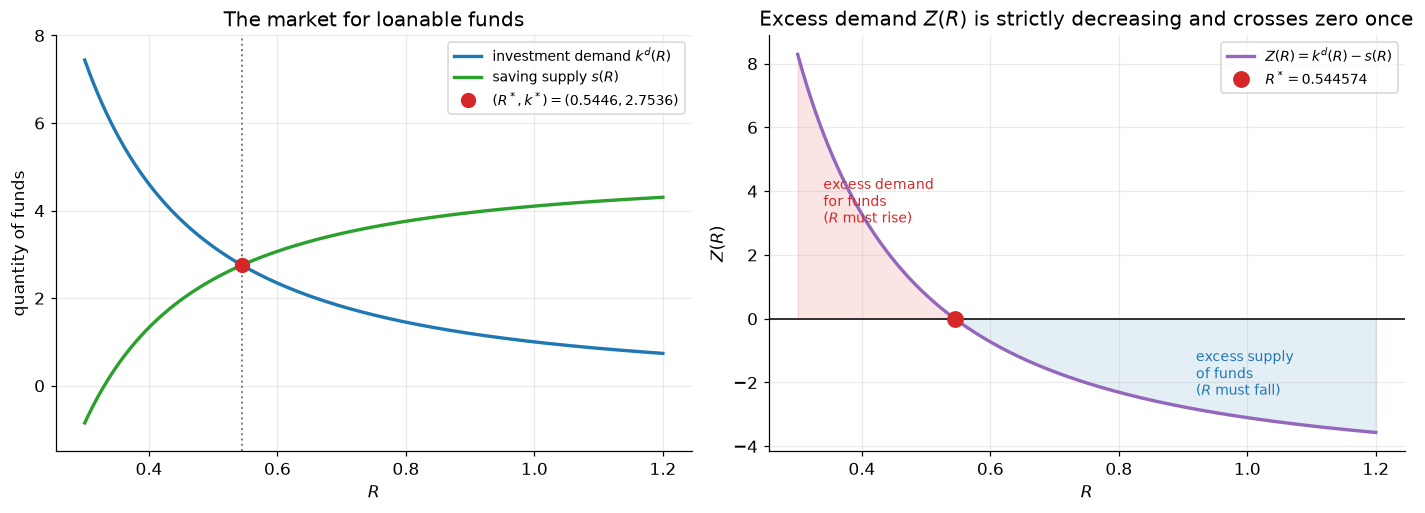

Z(0.30) =  8.287998   (positive: excess demand)
Z(1.20) = -3.566178   (negative: excess supply)
Z is monotone decreasing on the grid: True
sign change bracketed by [0.30, 1.20]: True


In [22]:
Rz = np.linspace(0.3, 1.2, 400)
Zv = Z(Rz)
kd = firm_at_R(Rz)[0]
sv = household_at_R(Rz)[2]

fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax[0].plot(Rz, kd, lw=2.2, color="tab:blue", label=r"investment demand $k^d(R)$")
ax[0].plot(Rz, sv, lw=2.2, color="tab:green", label=r"saving supply $s(R)$")
ax[0].axvline(R_ast, color="0.5", ls=":", lw=1.3)
ax[0].plot(R_ast, k_star, "o", color="tab:red", ms=9, zorder=5,
           label=rf"$(R^*,k^*)=({R_ast:.4f},{k_star:.4f})$")
ax[0].set_xlabel(r"$R$")
ax[0].set_ylabel("quantity of funds")
ax[0].set_title("The market for loanable funds")
ax[0].legend(fontsize=9)
ax[0].set_ylim(-1.5, 8.0)

ax[1].plot(Rz, Zv, lw=2.2, color="tab:purple", label=r"$Z(R)=k^d(R)-s(R)$")
ax[1].axhline(0, color="k", lw=1.0)
ax[1].fill_between(Rz, Zv, 0, where=Zv > 0, color="tab:red", alpha=0.12)
ax[1].fill_between(Rz, Zv, 0, where=Zv < 0, color="tab:blue", alpha=0.12)
ax[1].plot(R_ast, 0.0, "o", color="tab:red", ms=10, zorder=5,
           label=rf"$R^*={R_ast:.6f}$")
ax[1].text(0.34, 3.0, "excess demand\nfor funds\n($R$ must rise)", fontsize=9,
           color="tab:red")
ax[1].text(0.92, -2.4, "excess supply\nof funds\n($R$ must fall)", fontsize=9,
           color="tab:blue")
ax[1].set_xlabel(r"$R$")
ax[1].set_ylabel(r"$Z(R)$")
ax[1].set_title(r"Excess demand $Z(R)$ is strictly decreasing and crosses zero once")
ax[1].legend(fontsize=9, loc="upper right")

fig.tight_layout()
plt.show()

print(f"Z(0.30) = {Z(0.30): .6f}   (positive: excess demand)")
print(f"Z(1.20) = {Z(1.20): .6f}   (negative: excess supply)")
print(f"Z is monotone decreasing on the grid: {bool(np.all(np.diff(Zv) < 0))}")
print(f"sign change bracketed by [0.30, 1.20]: {Z(0.30) * Z(1.20) < 0}")

**Answer (b).** $Z$ is continuous and **strictly decreasing** on $[0.3,1.2]$ (verified numerically at
all 400 grid points), with $Z(0.30)=+8.29>0$ and $Z(1.20)=-3.57<0$. By the intermediate value theorem
there is a root in the interval, and by strict monotonicity it is unique. Economically: the demand
curve for funds slopes down (diminishing marginal product of capital) while the supply curve slopes
up (higher $R$ reduces firm profit, hence household wealth, hence $c_0$), so the two cross exactly
once. Note that $s(R)$ is negative for very low $R$: when the interest rate is tiny, firm profits are
enormous, the household feels rich, and it wants to consume more than the entire date-0 endowment.

### (c)
Use a root-finding routine such as `brentq` to solve $Z(R)=0$. Explain why the root is an equilibrium.

In [23]:
# Bracket chosen from the signs above: Z(0.30) > 0 > Z(1.20)
R_eq, info = brentq(Z, 0.30, 1.20, xtol=1e-15, rtol=8.9e-16, full_output=True)

print(f"brentq root  R_eq = {R_eq:.14f}")
print(f"Z(R_eq)           = {Z(R_eq):.3e}")
print(f"iterations        = {info.iterations},  function calls = {info.function_calls},"
      f"  converged = {info.converged}")

k_eq, y1_eq, pi_eq = firm_at_R(R_eq)
c0_eq, c1_eq, s_eq = household_at_R(R_eq)

print("\n--- the equilibrium allocation ---")
print(f"R_eq   = {R_eq:.10f}     r_eq = {R_eq - 1:.10f}")
print(f"k^d    = {k_eq:.10f}     s = {s_eq:.10f}     gap = {k_eq - s_eq:.3e}")
print(f"c0     = {c0_eq:.10f}")
print(f"c1     = {c1_eq:.10f}     f(k) = {y1_eq:.10f}     gap = {c1_eq - y1_eq:.3e}")
print(f"profit = {pi_eq:.10f}")
print(f"U      = {U(c0_eq, c1_eq, beta3):.10f}")

print("\n--- all equilibrium conditions ---")
print(f"household Euler   1/c0 - beta*R/c1  = {1 / c0_eq - beta3 * R_eq / c1_eq:.3e}")
print(f"firm FOC          f'(k) - R         = {fprime(k_eq) - R_eq:.3e}")
print(f"credit market     s - k             = {s_eq - k_eq:.3e}")
print(f"goods, date 0     y0 - c0 - k       = {y0 - c0_eq - k_eq:.3e}")
print(f"goods, date 1     f(k) - c1         = {y1_eq - c1_eq:.3e}")

brentq root  R_eq = 0.54457449055565
Z(R_eq)           = -1.776e-15
iterations        = 11,  function calls = 12,  converged = True

--- the equilibrium allocation ---
R_eq   = 0.5445744906     r_eq = -0.4554255094
k^d    = 2.7536231884     s = 2.7536231884     gap = -1.776e-15
c0     = 7.2463768116
c1     = 3.7488823625     f(k) = 3.7488823625     gap = 8.882e-16
profit = 4.1304347826
U      = 3.2358864648

--- all equilibrium conditions ---
household Euler   1/c0 - beta*R/c1  = 0.000e+00
firm FOC          f'(k) - R         = 0.000e+00
credit market     s - k             = 1.776e-15
goods, date 0     y0 - c0 - k       = 1.776e-15
goods, date 1     f(k) - c1         = -8.882e-16


**Answer (c).** `brentq` returns
$$
\boxed{R_{\text{eq}}=0.54457449\ldots}\qquad Z(R_{\text{eq}})=-1.8\times10^{-15},
$$
in 11 iterations and 12 function calls, with allocation $k=2.7536232$, $c_0=7.2463768$,
$c_1=3.7488824$ — precisely the planner allocation.

**Why the root is an equilibrium.** A competitive equilibrium is a *price* plus an *allocation* such
that (i) the household optimizes given the price, (ii) the firm optimizes given the price, and (iii)
markets clear. Conditions (i) and (ii) are built into the functions `household_at_R` and `firm_at_R`:
at *every* $R$ we feed the solver, both agents are already at their private optima — that is what
makes the exercise about *disequilibrium in prices*, not about irrational behavior. The only condition
left to impose is (iii), market clearing in the single asset market, which is exactly $Z(R)=0$.
Therefore solving $Z(R)=0$ *is* solving for the equilibrium price, and the resulting quantities
constitute the equilibrium allocation. Walras's law does the rest: with two goods markets and one
asset market, once the asset market clears, both goods markets clear automatically — which the printed
residuals ($\le10^{-15}$) confirm.

`brentq` is appropriate because it needs only continuity and a sign-changing bracket (which we
verified in part (b)); it combines the guaranteed convergence of bisection with the speed of the
secant/inverse-quadratic steps, and requires no derivative of $Z$.

### (d)
Compare the market-clearing interest rate with $R^*=f'(k_0^*)$. Explain why they agree.

In [24]:
print(f"market-clearing rate   R_eq = {R_eq:.16f}")
print(f"planner shadow price   R*   = {R_ast:.16f}")
print(f"absolute difference         = {abs(R_eq - R_ast):.3e}")
print(f"relative difference         = {abs(R_eq - R_ast) / R_ast:.3e}")
print(f"machine epsilon             = {np.finfo(float).eps:.3e}")

print(f"\nallocation comparison")
print(f"{'':<6}{'equilibrium':>16}{'planner':>16}{'|diff|':>14}")
for lab, a, b in (("k0", k_eq, k_star), ("c0", c0_eq, c0_p), ("c1", c1_eq, c1_p),
                  ("U", U(c0_eq, c1_eq, beta3), U_p)):
    print(f"{lab:<6}{a:>16.10f}{b:>16.10f}{abs(a - b):>14.3e}")

market-clearing rate   R_eq = 0.5445744905556523
planner shadow price   R*   = 0.5445744905556522
absolute difference         = 1.110e-16
relative difference         = 2.039e-16
machine epsilon             = 2.220e-16

allocation comparison
           equilibrium         planner        |diff|
k0        2.7536231884    2.7536231884     1.332e-15
c0        7.2463768116    7.2463768116     8.882e-16
c1        3.7488823625    3.7488823625     4.441e-16
U         3.2358864648    3.2358864648     0.000e+00


**Answer (d).** $R_{\text{eq}}=R^*$ to $10^{-16}$ — the difference is at machine epsilon, i.e. they
are the same number.

**Why they must agree.** Follow the logic in three steps.

1. At any $R$, the firm's FOC gives $f'(k^d(R))=R$. So at the market-clearing rate,
   $R_{\text{eq}}=f'(k^d(R_{\text{eq}}))$: the equilibrium rate *is* the marginal product of capital
   at the equilibrium capital stock, whatever that turns out to be.
2. Market clearing forces the equilibrium capital stock to be the planner's. Substituting $s=k$ into
   the household's constraints gives $c_0=y_0-k$ and $c_1=Rs+D_1=Rk+(f(k)-Rk)=f(k)$ — precisely the
   planner's two resource constraints. Combining these with the household's Euler equation
   $c_1=\beta R c_0$ and the firm's $R=f'(k)$ yields
   $f(k)=\beta f'(k)(y_0-k)$, which *is* the planner's first-order condition. Since that condition
   has a unique solution, $k^{\text{eq}}=k_0^*$.
3. Hence $R_{\text{eq}}=f'(k^{\text{eq}})=f'(k_0^*)=R^*$.

**Interpretation.** The equilibrium price is the planner's shadow price. In the planner's problem
$f'(k_0^*)=\lambda_0/\lambda_1$ measures, in utils, the relative social value of a date-0 versus a
date-1 good; it is a *virtual* price, internal to the optimization. In the market economy the very
same number appears as an *observable* market price at which real trades occur. The correspondence
between shadow prices of a concave planning problem and equilibrium prices of a competitive economy is
the content of the two welfare theorems and, more generally, of Lagrangian duality: the planner's
multipliers are the market's prices.

A practical corollary: to compute the equilibrium of this economy you never needed to solve a fixed
point in prices at all. Solve the planner's one-variable concave program and read the price off the
FOC. That shortcut is used throughout quantitative macroeconomics.

### (e)
Choose $R_L<R^*$ and $R_H>R^*$. Report saving and investment and interpret the imbalance.

In [25]:
R_L, R_H = 0.40, 0.80

print(f"{'':<22}{'R_L = 0.40':>16}{'R* = ' + f'{R_ast:.4f}':>16}{'R_H = 0.80':>16}")
rows = []
for Rq in (R_L, R_ast, R_H):
    k, y1, pi = firm_at_R(Rq)
    c0q, c1q, sq = household_at_R(Rq)
    rows.append((k, sq, k - sq, pi, c0q, y0 - c0q - k))

labels = ["investment  k^d(R)", "saving      s(R)", "excess demand Z(R)",
          "firm profit pi(R)", "consumption c0(R)", "date-0 goods gap"]
for idx, lab in enumerate(labels):
    print(f"{lab:<22}" + "".join(f"{rows[j][idx]:>16.6f}" for j in range(3)))

print(f"\nZ(R_L) = {Z(R_L): .6f}  -> excess DEMAND for funds  ({Z(R_L) / firm_at_R(R_L)[0]:.1%} of k^d)")
print(f"Z(R*)  = {Z(R_ast): .3e}  -> market clears")
print(f"Z(R_H) = {Z(R_H): .6f}  -> excess SUPPLY of funds   ({-Z(R_H) / household_at_R(R_H)[2]:.1%} of s)")

                            R_L = 0.40     R* = 0.5446      R_H = 0.80
investment  k^d(R)            4.605039        2.753623        1.450497
saving      s(R)              1.329457        2.753623        3.756028
excess demand Z(R)            3.275582        0.000000       -2.305532
firm profit pi(R)             6.907559        4.130435        2.175745
consumption c0(R)             8.670543        7.246377        6.243972
date-0 goods gap             -3.275582        0.000000        2.305532

Z(R_L) =  3.275582  -> excess DEMAND for funds  (71.1% of k^d)
Z(R*)  =  0.000e+00  -> market clears
Z(R_H) = -2.305532  -> excess SUPPLY of funds   (61.4% of s)


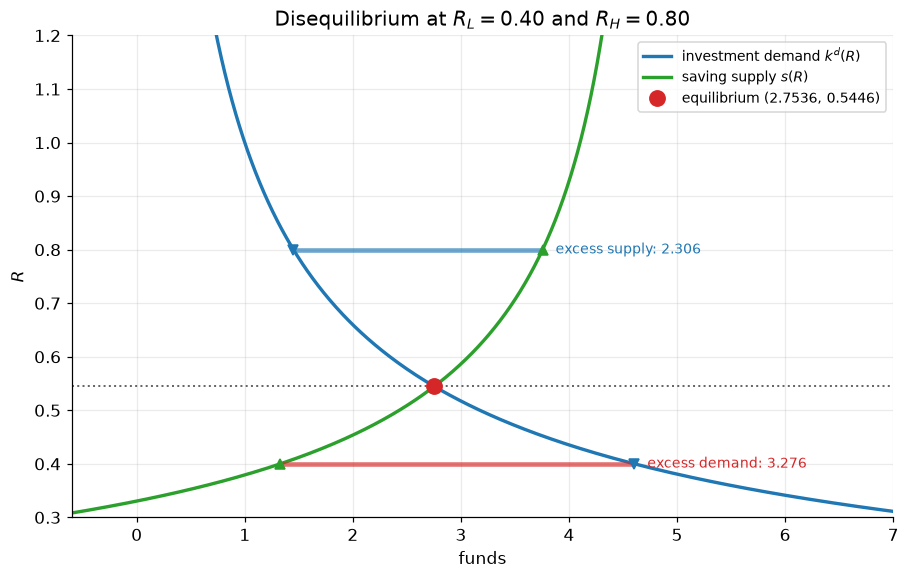

In [26]:
fig, ax = plt.subplots(figsize=(8.4, 5.4))

ax.plot(kd, Rz, lw=2.2, color="tab:blue", label=r"investment demand $k^d(R)$")
ax.plot(sv, Rz, lw=2.2, color="tab:green", label=r"saving supply $s(R)$")
ax.axhline(R_ast, color="0.4", ls=":", lw=1.3)
ax.plot(k_star, R_ast, "o", color="tab:red", ms=10, zorder=6,
        label=rf"equilibrium $({k_star:.4f},\,{R_ast:.4f})$")

for Rq, col, txt in ((R_L, "tab:red", "excess demand"), (R_H, "tab:blue", "excess supply")):
    kq = firm_at_R(Rq)[0]
    sq = household_at_R(Rq)[2]
    ax.hlines(Rq, min(kq, sq), max(kq, sq), color=col, lw=3, alpha=0.65)
    ax.plot([kq], [Rq], "v", color="tab:blue", ms=7)
    ax.plot([sq], [Rq], "^", color="tab:green", ms=7)
    ax.text(max(kq, sq) + 0.12, Rq, f"{txt}: {abs(kq - sq):.3f}", va="center",
            fontsize=9, color=col)

ax.set_xlim(-0.6, 7.0)
ax.set_ylim(0.3, 1.2)
ax.set_xlabel("funds")
ax.set_ylabel(r"$R$")
ax.set_title("Disequilibrium at $R_L=0.40$ and $R_H=0.80$")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

**Answer (e).**

| | $R_L=0.40$ | $R^*=0.5446$ | $R_H=0.80$ |
|---|---|---|---|
| investment $k^d(R)$ | $4.6050$ | $2.7536$ | $1.4505$ |
| saving $s(R)$ | $1.3295$ | $2.7536$ | $3.7560$ |
| excess demand $Z(R)$ | $+3.2756$ | $0$ | $-2.3055$ |
| firm profit $\pi(R)$ | $6.9076$ | $4.1304$ | $2.1757$ |
| $c_0(R)$ | $8.6705$ | $7.2464$ | $6.2440$ |

**At $R_L=0.40<R^*$: excess demand for funds** of $3.2756$ (about $71\%$ of desired investment).
Credit is cheap, so the firm wants to borrow a great deal ($k^d=4.6050$, the scale at which the
marginal product has fallen all the way to $0.40$). At the same time the low rate makes the firm
highly profitable ($\pi=6.9076$), the household feels wealthy ($W^h=16.9076$) and wants to consume
$8.6705$ of the $10$ available, saving only $1.3295$. Investment plans exceed available resources: the
date-0 goods market does not balance ($y_0-c_0-k=-3.2756<0$, an *infeasible* plan). Competition for
scarce funds bids the interest rate **up**.

**At $R_H=0.80>R^*$: excess supply of funds** of $2.3055$ (about $61\%$ of desired saving). Borrowing
is expensive, so the firm scales back to $k^d=1.4505$. Meanwhile the household, poorer (profits fall
to $2.1757$) and facing a high reward for postponing consumption, cuts $c_0$ to $6.2440$ and offers
$3.7560$ of saving. There are more funds seeking a return than projects worth financing; the date-0
constraint slackens ($y_0-c_0-k=+2.3055>0$: goods are literally left unused). Lenders compete and the
interest rate is bid **down**.

**Interpretation.** Only at $R^*$ do the two plans mesh, and only then is the allocation feasible *and*
Pareto efficient. Away from $R^*$, agents are still individually rational — each is at its own
optimum given the wrong price — yet the *aggregate* is incoherent. This is the essential point about
prices in general equilibrium: individual optimality is not enough, and the interest rate is the
variable that must move to reconcile independently made plans. Notice also that $Z'(R)<0$ makes the
usual Walrasian tâtonnement story ("raise $R$ when $Z>0$") locally *and* globally stable here, which
is why a simple root-finder works so cleanly.

---
# Problem 6. The First Welfare Theorem — What the Computer Does Not Prove

### (a)
Generate 100,000 random feasible allocations and compare the best one with the planner optimum.

In [27]:
rng = np.random.default_rng(5040)
N = 100_000

# 1 -------- feasible investment levels k0 in (0, y0)
k_rand = rng.uniform(1e-9, y0 - 1e-9, N)

# 2 -------- feasible c0 and c1 conditional on k0.
#            Feasibility only requires c0 <= y0 - k0 and c1 <= f(k0) (free disposal
#            allowed), so we scale each by an independent uniform draw.
theta0 = rng.uniform(0.0, 1.0, N)
theta1 = rng.uniform(0.0, 1.0, N)
c0_rand = theta0 * (y0 - k_rand)
c1_rand = theta1 * f(k_rand)

# 3 -------- evaluate utility
Ur = U(c0_rand, c1_rand, beta3)
best = int(np.argmax(Ur))

print("--- interior draws (free disposal permitted) ---")
print(f"draws                       : {N:,}")
print(f"best random utility         : {Ur[best]:.10f}")
print(f"  at (c0, c1, k0)           : ({c0_rand[best]:.6f}, {c1_rand[best]:.6f}, "
      f"{k_rand[best]:.6f})")
print(f"planner utility U*          : {U_p:.10f}")
print(f"  at (c0*, c1*, k0*)        : ({c0_p:.6f}, {c1_p:.6f}, {k_star:.6f})")
print(f"utility shortfall U* - best : {U_p - Ur[best]:.6e}")
print(f"any draw beats the planner? : {bool(np.any(Ur > U_p + 1e-12))}")
print(f"feasibility violations      : "
      f"{int(np.sum((c0_rand + k_rand > y0 + 1e-12) | (c1_rand > f(k_rand) + 1e-12)))}")

# 4 -------- a harder test: draws restricted to the PPF (no waste), so only the
#            single margin k0 is randomized
Uf = U(y0 - k_rand, f(k_rand), beta3)
bf = int(np.argmax(Uf))
print("\n--- draws on the frontier (c0 = y0 - k, c1 = f(k)) ---")
print(f"best frontier utility       : {Uf[bf]:.12f}   at k0 = {k_rand[bf]:.8f}")
print(f"utility shortfall U* - best : {U_p - Uf[bf]:.6e}")
print(f"|k_best - k0*|              : {abs(k_rand[bf] - k_star):.6e}")
print(f"any draw beats the planner? : {bool(np.any(Uf > U_p + 1e-12))}")

# 5 -------- how fast does random search approach the optimum?
print("\n--- best-so-far as N grows (frontier draws) ---")
for n in (10, 100, 1_000, 10_000, 100_000):
    print(f"  N = {n:>7,}:  best U = {Uf[:n].max():.10f},  gap = {U_p - Uf[:n].max():.3e}")

--- interior draws (free disposal permitted) ---
draws                       : 100,000
best random utility         : 3.2073385105
  at (c0, c1, k0)           : (7.139205, 3.695411, 2.735925)
planner utility U*          : 3.2358864648
  at (c0*, c1*, k0*)        : (7.246377, 3.748882, 2.753623)
utility shortfall U* - best : 2.854795e-02
any draw beats the planner? : False
feasibility violations      : 0

--- draws on the frontier (c0 = y0 - k, c1 = f(k)) ---
best frontier utility       : 3.235886464771   at k0 = 2.75360752
utility shortfall U* - best : 8.493650e-12
|k_best - k0*|              : 1.567228e-05
any draw beats the planner? : False

--- best-so-far as N grows (frontier draws) ---
  N =      10:  best U = 3.2345670143,  gap = 1.319e-03
  N =     100:  best U = 3.2357222394,  gap = 1.642e-04
  N =   1,000:  best U = 3.2358766073,  gap = 9.858e-06
  N =  10,000:  best U = 3.2358864639,  gap = 8.315e-10
  N = 100,000:  best U = 3.2358864648,  gap = 8.494e-12


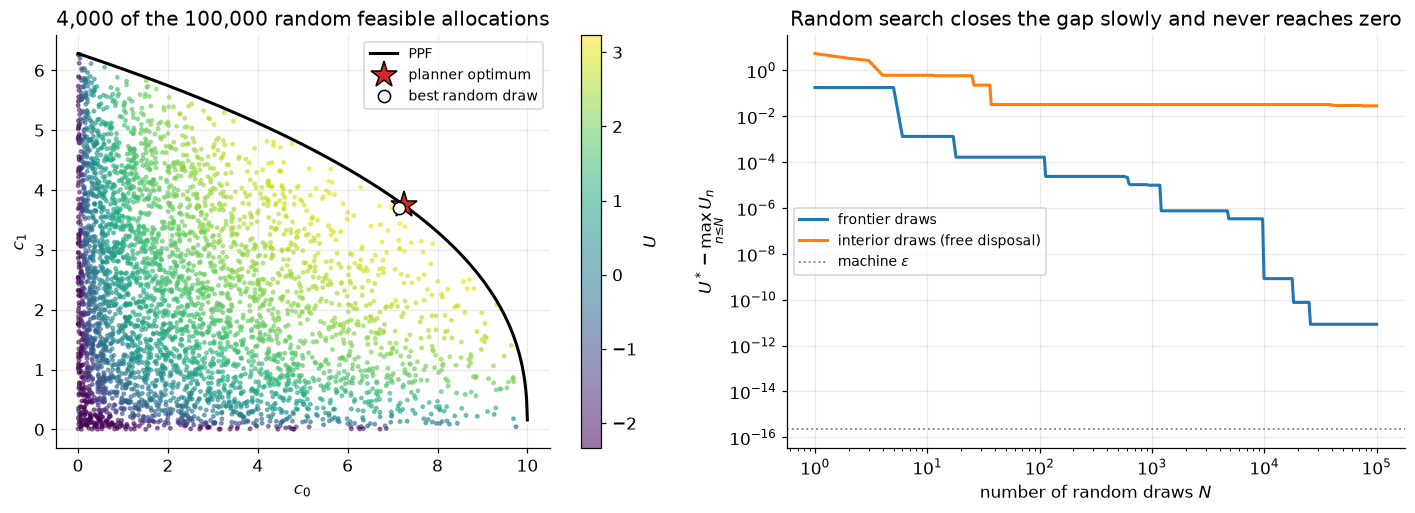

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.8))

sub = rng.choice(N, 4000, replace=False)
sc = ax[0].scatter(c0_rand[sub], c1_rand[sub], c=Ur[sub], s=5, cmap="viridis",
                   alpha=0.55, vmin=np.percentile(Ur, 5), vmax=U_p)
ax[0].plot(c0_vals, ppf, lw=2, color="k", label=r"PPF")
ax[0].plot(c0_p, c1_p, "*", color="tab:red", ms=18, mec="k", zorder=6,
           label="planner optimum")
ax[0].plot(c0_rand[best], c1_rand[best], "o", color="white", mec="k", ms=8, zorder=6,
           label="best random draw")
ax[0].set_xlabel(r"$c_0$")
ax[0].set_ylabel(r"$c_1$")
ax[0].set_title("4,000 of the 100,000 random feasible allocations")
ax[0].legend(fontsize=9, loc="upper right")
fig.colorbar(sc, ax=ax[0], label=r"$U$")

ns = np.unique(np.geomspace(1, N, 400).astype(int))
ax[1].semilogx(ns, U_p - np.maximum.accumulate(Uf)[ns - 1], lw=2, color="tab:blue",
               label="frontier draws")
ax[1].semilogx(ns, U_p - np.maximum.accumulate(Ur)[ns - 1], lw=2, color="tab:orange",
               label="interior draws (free disposal)")
ax[1].set_yscale("log")
ax[1].axhline(np.finfo(float).eps, color="0.5", ls=":", lw=1.2,
              label=r"machine $\varepsilon$")
ax[1].set_xlabel("number of random draws $N$")
ax[1].set_ylabel(r"$U^* - \max_{n\leq N} U_n$")
ax[1].set_title("Random search closes the gap slowly and never reaches zero")
ax[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

**Answer (a).**

With $100{,}000$ draws:

* **Interior draws** (free disposal allowed, so three dimensions randomized): the best draw attains
  $U=3.2073385$ against the planner's $U^*=3.2358865$, a shortfall of $2.85\times10^{-2}$. Even the
  best of $100{,}000$ draws still throws away $1.7\%$ of $c_0$ and $1.2\%$ of $c_1$.
* **Frontier draws** (no waste, only $k_0$ randomized): the best attains
  $U^*-8.5\times10^{-12}$, with $|k_{\text{best}}-k_0^*|\approx1.6\times10^{-5}$.
* **No draw ever exceeds the planner's utility**, and zero draws violate feasibility.
* The right panel shows the shortfall falling from $1.3\times10^{-3}$ at $N=10$ to
  $8.5\times10^{-12}$ at $N=10^{5}$ in the one-dimensional case — very roughly like $N^{-2}$, though
  noisily, since it is an extreme-order statistic — and far more slowly in the three-dimensional case.
  It is always strictly above zero.

The pattern is exactly what theory predicts: the planner's value is an upper bound on utility over the
feasible set, random feasible points approach it but (with probability one) never attain it, and the
rate of approach deteriorates sharply with dimension. Note also *why* the frontier draws do so much
better: the objective is flat to second order at the optimum, so a $1.6\times10^{-5}$ error in $k_0$
costs only $\sim10^{-11}$ in utility. That flatness is a blessing for search and a curse for
identification.

### (b)
Does this prove global optimality? Explain.

**Answer (b).** **No.** The computation is *consistent with* global optimality but does not establish
it.

**What the experiment actually shows.** We sampled $100{,}000$ points from a continuum. The feasible
set has the cardinality of the continuum, so we examined a set of **measure zero**. All we have
learned is: "no point in this particular finite sample beats the candidate." Logically this is a
failure to refute, not a proof. Formally, random search gives a *stochastic lower bound*
$\max_n U_n \le U^*$; it can never certify the reverse inequality.

**Why the sample can be misleading in general.**
* Random search is subject to the curse of dimensionality: to guarantee that some draw lands within
  $\varepsilon$ of the optimum in $d$ dimensions requires on the order of $\varepsilon^{-d}$ draws.
  Here $d$ is $1$ or $3$ and things look fine; in a realistic model with $d=50$ the same experiment
  would be worthless.
* A narrow spike of high utility (or one located in a low-probability region of the sampling
  distribution) could be missed entirely. Our sampling distribution was *chosen by us*; a different
  distribution explores differently.
* Uniform draws on $(0,y_0)$ concentrate nowhere in particular; the fact that the best draw was near
  $k_0^*$ is informative but not conclusive.

**What does prove it — an actual argument.** Global optimality here follows from three facts, none of
them numerical:

1. **Existence.** Restrict attention to $k_0\in[\delta,y_0-\delta]$; the objective
   $G(k_0)=\log(y_0-k_0)+\alpha\beta\log k_0+\beta\log A$ is continuous on this compact set, so by
   Weierstrass a maximum exists. Since $G\to-\infty$ as $k_0\to0^+$ or $k_0\to y_0^-$, the maximum is
   interior for small enough $\delta$.
2. **Strict concavity.** $G''(k_0)=-\dfrac{1}{(y_0-k_0)^{2}}-\dfrac{\alpha\beta}{k_0^{2}}<0$ on
   $(0,y_0)$. (Equivalently: $U$ is strictly concave and increasing, the feasible set
   $\{(c_0,c_1):c_0+k_0\le y_0,\ c_1\le f(k_0),\ k_0\ge0\}$ is convex because $f$ is concave.)
3. **Sufficiency of the FOC.** For a strictly concave differentiable function on a convex set, any
   stationary point is the *unique global* maximum. We found $G'(k_0^*)=0$ analytically, so
   $k_0^*=\frac{\alpha\beta y_0}{1+\alpha\beta}$ is the global maximizer — for **all** parameter values,
   not just these.

That is a proof. The 100,000 draws are a *sanity check on the code*: they would have caught a sign
error or a mis-typed formula. That is a genuine and valuable role, but it is a different role from
proof. Computation and theory are complements: theory tells you what must be true, computation tells
you whether you implemented it.

### (c)
Does numerical coincidence prove the First Welfare Theorem? Explain.

**Answer (c).** **No.** In Problem 4 we found agreement to $10^{-16}$ between the competitive
equilibrium and the planner allocation. This is compelling evidence that our algebra and our code are
right. It is not a proof of the First Welfare Theorem, for several distinct reasons.

1. **A single parameter point is not a universal quantifier.** We verified the claim at
   $(A,\alpha,\beta,y_0)=(2.5,0.4,0.95,10)$. The theorem asserts something for *every* economy in a
   large class — any number of goods, dates, and consumers; any continuous, locally non-satiated
   preferences; any technology. One point cannot certify a statement quantified over an
   infinite-dimensional space. Even scanning a fine grid of parameters would only add points, never
   the quantifier.
2. **Verification is not explanation.** The theorem's proof is a two-line contradiction argument (see
   part (d)) that reveals *why* the result holds: at common prices, any Pareto-improving allocation
   would have to be affordable and preferred, contradicting utility maximization. The number
   $10^{-16}$ tells us nothing about the mechanism, so it teaches us nothing about when the mechanism
   fails.
3. **A proof identifies its own assumptions; a computation hides them.** The proof needs
   price-taking, complete markets, no externalities, local non-satiation, and a common price vector.
   Our code silently satisfies all of these because we built them in — one $R$ faced by both agents,
   no untraded commodity, no externality. We could not have discovered the assumptions by computing;
   we can only discover them by proving.
4. **Floating-point agreement is not mathematical identity.** Getting $10^{-16}$ means "the two
   computations agree to within rounding," which is the strongest possible numerical statement and
   still logically weaker than "equal." Conversely, a *disagreement* of $10^{-6}$ might reflect solver
   tolerance rather than economics — numerics can neither confirm nor refute cleanly.
5. **The logic runs the other way.** We used the theorem to *design* the experiment: we set
   $R^*=f'(k_0^*)$ using the planner's solution and then confirmed the household chose $c_0^*$.
   Confirming a prediction of a theorem you assumed is not a proof of the theorem. (It *is* a good
   test of the implementation — which is the honest description of what we did.)

**What computation is genuinely for.** Testing implementations; exploring cases where no closed form
exists; producing quantitative magnitudes ("how large is the welfare loss?"); generating conjectures;
and — importantly — *falsification*. Had the numbers disagreed, we would have learned something
immediately: either a bug, or a violated assumption. Computation can refute; only proof can establish.

### (d)
State the First Welfare Theorem and explain Pareto efficiency in this one-consumer economy.

**Answer (d).**

**First Welfare Theorem (statement).** Consider a private-ownership economy with a finite set of
consumers $i=1,\dots,I$ with preferences $\succeq_i$ that are *locally non-satiated*, a finite set of
firms $j=1,\dots,J$ with production sets $Y_j$, and a complete set of competitive markets for all
commodities. If $\big(p^*,(x_i^*),(y_j^*)\big)$ is a competitive equilibrium — that is,

1. each consumer $i$ maximizes $\succeq_i$ over her budget set
   $\{x: p^*\!\cdot x\le p^*\!\cdot e_i+\sum_j\theta_{ij}\,p^*\!\cdot y_j^*\}$,
2. each firm $j$ maximizes profit $p^*\!\cdot y$ over $Y_j$,
3. markets clear, $\sum_i x_i^*=\sum_i e_i+\sum_j y_j^*$,

— then the allocation $\big((x_i^*),(y_j^*)\big)$ is **Pareto efficient**: there is no feasible
allocation that makes every consumer at least as well off and some consumer strictly better off.

Note what is *not* required: no convexity of preferences or production, no differentiability, no
uniqueness. Local non-satiation and *complete competitive markets* do all the work.

**Proof sketch (why it is true).** Suppose a feasible allocation $(x_i,y_j)$ Pareto-dominates the
equilibrium. Then $x_i\succeq_i x_i^*$ for all $i$ with strict preference for some $i$. Utility
maximization at $p^*$ implies $p^*\!\cdot x_i\ge p^*\!\cdot x_i^*$ for all $i$ (otherwise $x_i$ would
have been affordable *and* weakly better, and local non-satiation would have allowed a strictly better
affordable point), with strict inequality for the consumer who is strictly better off. Summing,
$p^*\!\cdot\sum_i x_i > p^*\!\cdot\sum_i x_i^*$. But profit maximization gives
$p^*\!\cdot y_j\le p^*\!\cdot y_j^*$ for all $j$, and feasibility of both allocations then implies
$p^*\!\cdot\sum_i x_i \le p^*\!\cdot(\sum_i e_i + \sum_j y_j)\le p^*\!\cdot(\sum_i e_i+\sum_j y_j^*)
= p^*\!\cdot\sum_i x_i^*$ — a contradiction. $\;\blacksquare$

**Pareto efficiency in *this* economy.** With $I=1$ (a representative consumer) Pareto efficiency
collapses to something much simpler and much stronger:

> An allocation is Pareto efficient $\iff$ it maximizes the single consumer's utility over the
> feasible set.

There is no one to trade off against, so the Pareto frontier is a single point and "efficient" means
"utility-maximizing subject to technology and resources." Concretely: an allocation $(c_0,c_1,k_0)$ is
Pareto efficient here iff
$$
c_0+k_0=y_0,\qquad c_1=f(k_0),\qquad \frac{c_1}{\beta c_0}=f'(k_0),
$$
i.e. iff no resources are wasted **and** $MRS=MRT$. Our equilibrium satisfies all three, so it is
efficient, and $U^{\text{eq}}=U^{\text{planner}}=3.2358865$ confirms it numerically.

**Two cautions about the one-consumer case.**
* The equivalence "efficient $=$ utility-maximizing" is a *special feature* of $I=1$, not a general
  truth. With $I\ge 2$ there is a whole continuum of Pareto-efficient allocations, one for each
  distribution of welfare weights, and the First Welfare Theorem says only that the equilibrium is
  *one* of them — it says nothing about which, and nothing about whether that one is desirable.
* Consequently, **efficiency is silent about equity**. In this economy the distinction is invisible
  because there is only one agent. That invisibility is exactly what makes the representative-agent
  benchmark so easy to over-interpret, which is the subject of part (e).

### (e)
Explain why the slogan "markets are efficient" is too loose. Mention at least two relevant assumptions or qualifications.

**Answer (e).**

The First Welfare Theorem is a *conditional* statement: **if** a long list of hypotheses holds, **then**
a competitive equilibrium is Pareto efficient. The slogan drops the "if" and, just as importantly,
overstates what "efficient" means. Several qualifications matter.

**1. Complete markets (the assumption that fails most often).** The theorem needs a market, with a
single common price, for *every* commodity — every good, at every date, in every state of the world.
Our model has exactly one asset market and it is enough. Real economies lack markets for many
future and state-contingent goods: you cannot buy insurance against being born with low ability, or
against a lifetime of poor labor-market luck. When a market is missing, individual optimization no
longer aligns $MRS$ with $MRT$ for the untraded commodity, and equilibria are generically inefficient.
Incomplete-markets models (Bewley, Aiyagari, Huggett) are built precisely on this failure and deliver
too little insurance and, often, too much precautionary saving.

**2. No externalities or public goods.** The theorem assumes each agent's utility and each firm's
technology depend only on its own actions. Carbon emissions, congestion, antibiotic resistance,
knowledge spillovers, financial contagion, and vaccination all violate this. With an externality, the
private $MRS$ or $MRT$ differs from the social one by exactly the uninternalized marginal damage, and
the equilibrium is inefficient in a *predictable direction* — which is what makes Pigouvian taxes and
Coasean bargaining meaningful. Public goods fail for a related reason (non-excludability breaks the
one-price-per-agent structure), giving the Samuelson condition $\sum_i MRS_i = MRT$ instead of
$MRS_i=MRT$.

**3. Price-taking / no market power.** Both our agents take $R$ as given. A monopolist sets
$MR=MC$ rather than $p=MC$, so $MRS>MRT$ at the equilibrium and output is too low. Search frictions,
bargaining, and strategic behavior break the theorem in the same way: the wedge between price and
marginal cost is exactly the inefficiency.

**4. Symmetric information.** Adverse selection and moral hazard mean the "same" good traded at the
"same" price is not actually the same commodity for both sides. Markets unravel (Akerlof) or
allocations distort (Rothschild–Stiglitz); equilibrium is generically inefficient.

**5. Efficiency is not welfare, and certainly not justice.** Even when the theorem applies in full, it
delivers Pareto efficiency and nothing more. Pareto efficiency is an extremely weak criterion: an
allocation in which one agent holds everything and the rest starve can be Pareto efficient. The
theorem is silent on distribution, on whether the initial endowments were justly acquired, and on any
notion of fairness. Our one-consumer economy makes this invisible — with $I=1$, "efficient" and
"good" coincide by construction — which is precisely why the representative-agent benchmark invites
over-reading. The Second Welfare Theorem's rejoinder ("any efficient allocation can be decentralized
after suitable transfers") requires convexity *and* lump-sum redistribution that no real government
can implement without distorting.

**6. Existence, uniqueness, and getting there.** The theorem presumes an equilibrium exists and that
the economy is *at* it. Existence needs convexity and continuity assumptions; uniqueness generally
fails (multiplicity, and with it coordination problems and self-fulfilling expectations); and nothing
in the theorem explains the *dynamics* by which prices reach $R^*$. Our $Z(R)$ was monotone, so
tâtonnement would converge — a special case, not a general result (Scarf's counterexamples show
instability is possible).

**7. Behavioral departures.** The theorem's "optimization" is genuine optimization of a stable
preference relation. Present bias, bounded attention, and framing effects break the link between
choice and welfare, so even a frictionless market can deliver an allocation that agents themselves
would not endorse.

**A more defensible slogan.** *"Competitive markets with a complete set of prices, no externalities,
no market power, and symmetric information deliver Pareto-efficient allocations — which says nothing
about distribution."* The theorem's real value is not as a blanket endorsement of markets but as a
**diagnostic**: it tells us exactly where to look. Whenever we observe an apparent inefficiency, we
should be able to point to a missing market, an externality, a wedge in $MRS=R=MRT$, or an
informational friction. If we cannot, we probably do not understand the problem yet.

---
# Problem 7. Synthesis

Write approximately 500 words answering:

> In this two-period economy, what economic role is played by the gross real interest rate?

Your answer should explain the connection among preferences, technology, prices, optimization, market clearing, and Pareto efficiency, and the meaning of

$$
\boxed{MRS=R=MRT.}
$$

## The gross real interest rate as the price of time

In this two-period economy the gross real interest rate $R$ is not a peripheral variable; it is *the*
price, and it is the object that makes decentralized intertemporal allocation possible. There is only
one non-trivial relative price in a two-good world, and here the two goods are the same physical
commodity at two different dates. $R$ is therefore the **price of present consumption in units of
future consumption**: giving up one unit today buys $R$ units tomorrow, and $1/R$ is the date-0 price
of a date-1 good. Every role $R$ plays follows from that single fact.

**Preferences: $R$ meets the marginal rate of substitution.** The household's willingness to trade
across dates is summarized by $MRS_{0,1}=\frac{u'(c_0)}{\beta u'(c_1)}=\frac{c_1}{\beta c_0}$ under
log utility. Facing $R$, the household equates $MRS=R$ — the Euler equation
$1/c_0=\beta R/c_1$ — and thereby chooses $c_0=\frac{W}{1+\beta}$ out of present-value wealth
$W$. $R$ enters twice: through *substitution* (a higher $R$ makes today expensive) and through
*wealth* ($W$ depends on $R$ whenever the income profile is not flat). In Problem 2 the agent's
endowment was future-weighted, so both channels pushed the same way and $c_0^*(R)$ fell monotonically;
saving rose monotonically and crossed zero at the autarky rate
$\widehat R=e_1/(\beta e_0)=1.5625$, the rate at which the household's internal valuation of time
exactly matches the market's.

**Technology: $R$ meets the marginal rate of transformation.** The firm's ability to move goods
across dates is $MRT_{0,1}=f'(k_0)$, the marginal product of capital. Present-value profit
maximization gives $f'(k_0)=R$, hence a downward-sloping demand for funds
$k^d(R)=(A\alpha/R)^{1/(1-\alpha)}$. Here $R$ is the *cost of capital*: it is the hurdle rate that
determines which projects are worth financing. Diminishing returns ($\alpha<1$) make this demand
well-behaved and the equilibrium unique.

**Market clearing and prices as information.** Neither agent knows the other's problem. The household
knows $\beta$; the firm knows $(A,\alpha)$. Yet because both face the same scalar $R$, their two
private conditions chain together:
$$
MRS=R=MRT .
$$
Equilibrium requires more than private optimality: it requires that the plans be mutually consistent,
$s(R)=k^d(R)$, i.e. $Z(R)=0$. Problem 5 showed why. At $R_L=0.40$ investment demand ($4.61$) swamped
saving ($1.33$) and the implied allocation was infeasible; at $R_H=0.80$ resources sat idle. Only at
$R^*=0.5446$ did the plans mesh. $R$ is the variable that reconciles independently made decisions —
Hayek's price system as a sufficient statistic, made arithmetic.

**Pareto efficiency: $R$ as a shadow price.** The planner never mentions prices; it directly imposes
$MRS=MRT$ and obtains $k_0^*=\frac{\alpha\beta y_0}{1+\alpha\beta}=2.7536$. Its Lagrange multipliers
satisfy $\lambda_0/\lambda_1=f'(k_0^*)$ — a virtual price. The remarkable finding is that this virtual
price *is* the market-clearing price: $R_{\text{eq}}=f'(k_0^*)=0.5445745$, agreeing to $10^{-16}$.
Duality is the reason: equilibrium prices are the shadow prices of the planner's concave program. This
is the First Welfare Theorem in miniature, and it is also a computational tool — solve the planner's
one-variable problem and read the price off the FOC.

So $MRS=R=MRT$ is not three facts but one, seen from three sides. Preferences determine what society
*wants* to do with time; technology determines what it *can* do; $R$ is the number at which those two
answers coincide, and the fact that a single number can do this is why prices, and not planners,
coordinate intertemporal choice. Break any link — an externality, a missing market, market power — and
the chain snaps at an identifiable point, which is exactly where the inefficiency lives.

---
# What surprised me?

Identify one result from the assignment that was not obvious to you before doing the computations. Explain what you now understand differently.

**The surprise: the equilibrium gross interest rate was less than one, and I could not have guessed the
sign of the net rate from intuition.**

Before computing, I had absorbed the reflex that "the interest rate equals the marginal product of
capital, and capital is productive, so $R>1$." When Problem 3 delivered $R^*=f'(k_0^*)=0.5446$ — a net
real rate of $-45.54\%$ — my first instinct was that I had made an algebra error. Checking it three
ways (closed form, `minimize_scalar`, `brentq` on the FOC) forced me to take the number seriously and
work out what it actually means.

What I now understand is that $R$ is not a measure of how good the technology is; it is a measure of
**scarcity at the margin, given the size of the endowment**. With $y_0=10$, $A=2.5$, and $\alpha=0.4$,
the economy is enormously capital-abundant relative to what the technology can usefully absorb. At the
optimum $k_0^*=2.75$ the *last* unit invested returns only $0.54$ units tomorrow. The economy still
invests, and invests a lot, not because investment is a good deal at the margin but because log
utility makes $c_1\to0$ catastrophic: the household's desperation to have *something* tomorrow drives
$k_0$ up until the marginal product has fallen far below one. The negative net rate is the price
signal saying "moving goods to the future is expensive here" — and $1/R^*=1.8363$ makes that literal:
a date-1 good costs $1.84$ date-0 goods.

Two related things clicked at the same time.

First, I had been conflating *average* and *marginal* productivity. Average product at $k_0^*$ is
$f(k_0^*)/k_0^*=1.3614$, comfortably above one, so the technology is not "bad." It is the marginal
product that prices the asset, and with $\alpha=0.4$ the marginal product is only $\alpha=40\%$ of the
average. Prices are marginal objects; my intuition was averaging.

Second, the comparative-statics exercise in 3(e) reframed the whole thing. Plotting
$R^*(\beta)$ falling from $0.7360$ to $0.5326$ as $\beta$ rose showed me that patience and interest
rates are *substitutes* in equilibrium: a more patient economy accumulates more capital and therefore
has a *lower* return, not a higher one. Written as the FOC $f'(k_0^*)=\frac{c_1^*}{\beta c_0^*}$, the
interest rate is visibly a *jointly determined* object — preferences on the right, technology on the
left — rather than a technological constant. I had been treating $R$ as an input to the household's
problem, which it is, while forgetting that in equilibrium it is an output of the whole system.

The methodological lesson is the one Problem 6 was designed to teach. The computation did not prove
anything; what it did was refuse to agree with my prior, which sent me back to the algebra until I
understood *why*. Getting a "wrong-looking" number and being unable to dismiss it was more instructive
than getting the number I expected. I will also be much slower, now, to assume that any equilibrium
price can be read off one side of the market.